In [ ]:
# NNSE Function-based Implementation for Tyson Model
# Implements a vector-based mutation and permutation algorithm
# Install required packages in the current environment (run once, then delete this cell)
import sys
import subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "tqdm", "ipywidgets", "joblib"])
print("✓ tqdm, ipywidgets, and joblib installed successfully")

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import copy
import time

# ============================================================================
# === CONFIGURATION VARIABLES ===
# ============================================================================

# Jackknife analysis control
JACKKNIFE = False  # Set to True to run jackknife analysis (multiple full simulations)

# Simulation settings
MAX_STEPS = 10000  # Maximum number of mutation steps (safety limit)
MIN_FILLED_POSITIONS = 29  # Continue until this many positions are filled (n - 2 for n=30)
STABILIZATION_STEPS = 2500  # Run this many additional steps after reaching MIN_FILLED_POSITIONS
SIGMA = 0.01  # Standard deviation for Gaussian mutations in normalized space
n_extra = 4  # Number of extra lower bins to prepend on the left
N_Vec = 30 + n_extra  # Number of bins for binning squared differences
MAX_VALUE = 15  # Maximum  value for bin thresholds (logspace goes from 0 to this)
K_INITIAL = 1  # Number of top positions to fill initially (top half)
T_START = 0.0  # Simulation start time
T_END = 500.0  # Simulation end time
N_TIME_POINTS = 501  # Number of time points

# Define bin thresholds: keep original 0.1..MAX_VALUE ladder and prepend extra smaller bins
# y0, y1, ..., yN_BINS: thresholds for binning
base_thresholds = np.logspace(np.log10(0.1), np.log10(MAX_VALUE), 31)
_ratio = base_thresholds[1] / base_thresholds[0]
_extra_low = base_thresholds[0] / (_ratio ** np.arange(n_extra, 0, -1))
bin_thresholds = np.concatenate([_extra_low, base_thresholds])
bin_thresholds[-1] = 1000.0
  # y0, y1, ..., yN_BINS, basically sets y0 to the value of y1 because function will likely never be zero

# ============================================================================
# === BASE PARAMETERS (p0) ===
# ============================================================================

p0 = {
    "k1_aa_over_CT": 0.015,
    "k2": 0.0,
    "k3_CT": 200.0,
    "k4": 180.0,
    "k4prime": 0.018,
    "k5_minusP": 0.0,
    "k6": 1.0,
    "k7": 0.6,
    "k8_minusP": 100.0,
    "k9": 50.0,
    "CT": 1.0
}

# Parameters to vary
param_names = [
    "k1_aa_over_CT",
    "k3_CT",
    "k4",
    "k4prime",
    "k6",
    "k7"
]

p0_vec = np.array([p0[name] for name in param_names])
n_params = len(param_names)

# Time evaluation array
t_eval = np.linspace(T_START, T_END, N_TIME_POINTS)

# ============================================================================
# === TYSON MODEL DEFINITION ===
# ============================================================================

CT = p0["CT"]

def F_M(M, p):
    """Helper function for M-dependent rate"""
    return p["k4prime"] + p["k4"] * (M / p["CT"])**2

def f_rhs(t, x, p):
    """Right-hand side of the ODE system"""
    # x = [C2, CP, pM, M, Y, YP]
    C2, CP, pM, M, Y, YP = x
    k3 = p["k3_CT"] / p["CT"]
    k1 = p["k1_aa_over_CT"] * p['CT']
    dC2 = p["k6"] * M - p["k8_minusP"] * C2 + p["k9"] * CP
    dCP = -k3 * CP * Y + p["k8_minusP"] * C2 - p["k9"] * CP
    dpM = k3 * CP * Y - pM * F_M(M, p) + p["k5_minusP"] * M
    dM  = pM * F_M(M, p) - p["k5_minusP"] * M - p["k6"] * M
    dY  = k1 - p["k2"] * Y - k3 * CP * Y
    dYP = p["k6"] * M - p["k7"] * YP
    return np.array([dC2, dCP, dpM, dM, dY, dYP])

def simulate_at_params(p_local, t_eval):
    """Simulate the ODE system with given parameters"""
    y0 = np.array([0.9, 0.05, 0.0, 0.005, 0.3, 0.0])
    sol = solve_ivp(lambda tt, xx: f_rhs(tt, xx, p_local), 
                    (t_eval[0], t_eval[-1]), y0,
                    method='BDF', t_eval=t_eval, rtol=1e-6, atol=1e-8)
    if not sol.success:
        raise RuntimeError("Integrator failed: " + sol.message)
    return sol.t, sol.y

def compute_obs(X):
    """Compute observables: YT/CT and M/CT"""
    if X.ndim == 1:
        C2, CP, pM, M, Y, YP = X
        YT = Y + YP + pM + M
        return YT / CT, M / CT
    else:
        C2, CP, pM, M, Y, YP = X
        YT = Y + YP + pM + M
        return YT / CT, M / CT

# ============================================================================
# === REFERENCE SIMULATION (p0) ===
# ============================================================================

print("Running reference simulation with p0...")
t0, y0 = simulate_at_params(p0, t_eval)
YT0, M0 = compute_obs(y0)
print(f"✓ Reference simulation complete")

# ============================================================================
# === SIM FUNCTION ===
# ============================================================================

def sim(P_vec):
    """
    Simulate with parameter vector P and compute squared difference with p0.
    Returns the squared difference (f(xi) value).
    """
    # Convert parameter vector to dictionary
    p_local = copy.deepcopy(p0)
    for i, name in enumerate(param_names):
        p_local[name] = P_vec[i]
    
    # Run simulation
    try:
        t, y = simulate_at_params(p_local, t_eval)
        YT, M = compute_obs(y)
        
        # Interpolate reference to match time points
        YT0_interp = np.interp(t, t0, YT0)
        M0_interp = np.interp(t, t0, M0)
        
        # Compute squared differences
        diff_YT_sq = (YT - YT0_interp)**2
        diff_M_sq = (M - M0_interp)**2
        
        # Integrate squared differences (trapezoid added in NumPy 2.0; fall back to trapz)
        _trapz = getattr(np, 'trapezoid', np.trapz)
        integral_YT_sq = _trapz(diff_YT_sq, t)
        integral_M_sq = _trapz(diff_M_sq, t)
        squared_diff = integral_YT_sq + integral_M_sq
        
        return squared_diff
        
    except Exception as e:
        # If simulation fails, return infinity
        print(f"Warning: Simulation failed: {e}")
        return np.inf

print(f"✓ Configuration complete")
print(f"  Parameters: {param_names}")
print(f"  Number of parameters: {n_params}")
print(f"  Bin thresholds (y0, ..., y{N_Vec}): [{bin_thresholds}]")
print()
print(f"  JACKKNIFE analysis: {'ENABLED' if JACKKNIFE else 'DISABLED'}")



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


✓ tqdm, ipywidgets, and joblib installed successfully
Running reference simulation with p0...
✓ Reference simulation complete
✓ Configuration complete
  Parameters: ['k1_aa_over_CT', 'k3_CT', 'k4', 'k4prime', 'k6', 'k7']
  Number of parameters: 6
  Bin thresholds (y0, ..., y34): [[5.12689589e-02 6.05885939e-02 7.16023456e-02 8.46181692e-02
 1.00000000e-01 1.18177929e-01 1.39660229e-01 1.65047567e-01
 1.95049796e-01 2.30505810e-01 2.72406993e-01 3.21924943e-01
 3.80444231e-01 4.49601113e-01 5.31329285e-01 6.27913945e-01
 7.42055697e-01 8.76946055e-01 1.03635669e+00 1.22474487e+00
 1.44737813e+00 1.71048150e+00 2.02141161e+00 2.38886238e+00
 2.82310809e+00 3.33629067e+00 3.94275923e+00 4.65947120e+00
 5.50646657e+00 6.50742816e+00 7.69034384e+00 9.08828909e+00
 1.07403518e+01 1.26927254e+01 1.00000000e+03]]

  JACKKNIFE analysis: DISABLED


In [31]:
# ============================================================================
# === TYSONFUNC: MUTATION AND PERMUTATION FUNCTION ===
# ============================================================================

import multiprocessing as mp

def _mutate_worker(args):
    """Worker function for parallel mutation."""
    i, xi, fxi, p0_vec_val, SIGMA_val, n_params_val, bin_thresholds_val = args
    
    if xi is None or fxi is None:
        return (i, None, None)
    
    u_vec = xi / (2.0 * p0_vec_val)
    u_mutated = (u_vec + np.random.normal(0, SIGMA_val, size=n_params_val)) % 1.0
    xi_prime = 2.0 * p0_vec_val * u_mutated
    fxi_prime = sim(xi_prime)
    
    if fxi_prime > bin_thresholds_val[i]:
        return (i, xi.copy(), fxi)
    else:
        return (i, xi_prime, fxi_prime)

def TysonFunc(X_list, fX_list, pool=None):
    """
    Mutate each parameter vector, evaluate, reject if worse, then permute.
    Also handles filling empty positions: if a swap involved an empty position,
    generates a new point and tries to place it as low as possible.
    
    Args:
        X_list: List of parameter vectors [x0, x1, ..., xn] where each xi is a numpy array (may be None)
        fX_list: List of function values [f(x0), f(x1), ..., f(xn)] (may be None)
    
    Returns:
        v_list: List of parameter vectors after mutation and permutation [v0, v1, ..., vn]
        fv_list: List of function values [f(v0), f(v1), ..., f(vn)]
        fX_prime_list: List of function values after mutation but before permutation [f(x'0), f(x'1), ..., f(x'n)]
        swaps: List of (i, j) tuples indicating which positions were swapped
    """
    n = len(X_list)
    
    # Step 1 & 2: Mutate each position
    if pool is not None:
        # PARALLEL: Use worker pool
        work_items = [
            (i, X_list[i], fX_list[i], p0_vec, SIGMA, n_params, bin_thresholds)
            for i in range(n) if X_list[i] is not None
        ]
        if work_items:
            results = pool.map(_mutate_worker, work_items)
            results_dict = {idx: (x, fx) for idx, x, fx in results}
        else:
            results_dict = {}
        X_prime_list = [results_dict.get(i, (None, None))[0] for i in range(n)]
        fX_prime_list = [results_dict.get(i, (None, None))[1] for i in range(n)]
    else:
        # SERIAL: Original loop
        X_prime_list = []
        fX_prime_list = []
        
        for i in range(n):
            xi = X_list[i]
            fxi = fX_list[i]
            
            # Skip empty positions
            if xi is None or fxi is None:
                X_prime_list.append(None)
                fX_prime_list.append(None)
                continue
            
            # Normalize parameters: u_i = p_i / (2 * p0_i) so each lies in [0,1]
            u_vec = xi / (2.0 * p0_vec)
            
            # Apply Gaussian mutation in u-space
            u_mutated = u_vec + np.random.normal(0, SIGMA, size=n_params)
            
            # Wrap around boundaries [0, 1] with periodic boundary conditions
            u_mutated = u_mutated % 1.0
            
            # Map back to parameter space: p_i = 2 * p0_i * u_i
            xi_prime = 2.0 * p0_vec * u_mutated
            
            # Evaluate mutated parameter: f(x'i) := sim(x'i)
            fxi_prime = sim(xi_prime)
            
            # Reject x'i if f(x'i) > y_i, otherwise accept
            if fxi_prime > bin_thresholds[i]:
                # Reject: keep original
                X_prime_list.append(xi.copy())
                fX_prime_list.append(fxi)
            else:
                # Accept: use mutated
                X_prime_list.append(xi_prime)
                fX_prime_list.append(fxi_prime)
    
    # Step 3: Permutation step
    # For each position i from n-1 down to 1 (0-indexed: n-1, n-2, ..., 1)
    # If f(x'_i) <= y_{i-1}, swap position i with position i-1

    v_list = X_prime_list.copy()
    fv_list = fX_prime_list.copy()

    # Track which positions were empty BEFORE swaps
    empty_before_swaps = set(i for i in range(n) if v_list[i] is None or fv_list[i] is None)

    # Track swaps
    swaps = []  # List of (i, j) tuples for swaps

    for i in range(n-1, 0, -1):  # i from n-1 down to 1
        # Skip if both positions are empty
        if fv_list[i] is None and fv_list[i-1] is None:
            continue
        
        # If f(x'_i) <= y_{i-1} and position i is not empty, swap
        if fv_list[i] is not None and fv_list[i] <= bin_thresholds[i-1]:
            # Swap position i with position i-1
            if v_list[i] is not None and v_list[i-1] is not None:
                v_list[i], v_list[i-1] = v_list[i-1].copy(), v_list[i].copy()
            else:
                v_list[i], v_list[i-1] = v_list[i-1], v_list[i]
            fv_list[i], fv_list[i-1] = fv_list[i-1], fv_list[i]
            swaps.append((i, i-1))  # Record the swap

    # Step 4: Fill positions that became empty due to swaps
    # Find positions that are empty AFTER swaps but were NOT empty BEFORE swaps
    empty_after_swaps = set(i for i in range(n) if v_list[i] is None or fv_list[i] is None)
    newly_empty_positions = empty_after_swaps - empty_before_swaps

    # For each newly empty position, generate a new point and place it as low as possible
    for empty_pos in newly_empty_positions:
        # Generate a new random point
        max_attempts = 1000
        for attempt in range(max_attempts):
            # Generate random point in normalized u-space [0, 1]
            u_random = np.random.uniform(0, 1, size=n_params)
            # Map to parameter space: p_i = 2 * p0_i * u_i
            x_new = 2.0 * p0_vec * u_random
            fx_new = sim(x_new)
            
            # Try to place it in the best (lowest index) position it can fit
            placed = False
            for pos in range(n):
                if fx_new <= bin_thresholds[pos]:
                    # Can place it at position pos
                    # If position is empty, place it
                    if v_list[pos] is None or fv_list[pos] is None:
                        v_list[pos] = x_new
                        fv_list[pos] = fx_new
                        placed = True
                        break
                    # If position has a worse value, replace it
                    elif fv_list[pos] is not None and fx_new < fv_list[pos]:
                        v_list[pos] = x_new
                        fv_list[pos] = fx_new
                        placed = True
                        break
            
            if placed:
                break
            # If we couldn't place it anywhere, try again with a new random point
    
    return v_list, fv_list, fX_prime_list, swaps

n_cores = mp.cpu_count()
print(f"✓ TysonFunc defined (parallel & serial modes)")
print(f"  Detected {n_cores} CPU cores available for parallel mode")


✓ TysonFunc defined (parallel & serial modes)
  Detected 12 CPU cores available for parallel mode


In [32]:
# ============================================================================
# === SIMULATION LOOP ===
# ============================================================================
# Note: fill_vacancies logic is now integrated into TysonFunc
import time
import multiprocessing as mp

try:
    from tqdm.notebook import tqdm
except ImportError:
    # Fallback to text-based progress bar if ipywidgets not available
    from tqdm import tqdm as tqdm_text
    tqdm = tqdm_text
    print("Note: Using text-based progress bar. For better display, install ipywidgets.")

# Helper function to format f values and y thresholds, handling None
def format_f_vals(fX_list, n):
    """Format f values and y thresholds for printing, handling None values.
    Returns two strings: (f_vals_str, y_vals_str)
    Always shows all f(xi) and y_i values.
    """
    indices = list(range(n))
    f_vals = [fX_list[i] if i < len(fX_list) else None for i in indices]
    f_vals_str = " ".join([f"{fx:<12.3e}" if fx is not None else f"{'---':<12}" for fx in f_vals])
    y_vals_str = " ".join([f"{bin_thresholds[i]:<12.3e}" for i in indices])
    return f_vals_str, y_vals_str

n = N_Vec  # Number of parameter vectors to maintain

print(f"Starting adaptive simulation with n={n} parameter vectors...")
print(f"  - Will run until {MIN_FILLED_POSITIONS}/{n} positions filled, then +{STABILIZATION_STEPS} steps")
print(f"  - Maximum steps: {MAX_STEPS}")

# Create persistent worker pool using 'fork' context
# ('spawn' is the macOS default but can't pickle notebook-defined functions)
ctx = mp.get_context('fork')
worker_pool = ctx.Pool(processes=mp.cpu_count())
print(f"✓ Created worker pool with {mp.cpu_count()} processes (fork)")

# Initialize: Only fill worst K positions (highest indices), leave best positions empty (None)
K = K_INITIAL
X_list = [None] * n
fX_list = [None] * n


# Generate K random points in the worst positions (highest indices, highest thresholds)
# Fill positions from n-K to n-1 (e.g., if n=50, K=25, fill positions 25-49)
# SPECIAL: Resample if initial fill would land in the last 2 worst bins (stuck risk)
for idx in range(n-K, n):
    max_init_attempts = 100
    for attempt in range(max_init_attempts):
        # Generate random point in normalized u-space [0, 1]
        u_random = np.random.uniform(0, 1, size=n_params)
        # Map to parameter space: p_i = 2 * p0_i * u_i
        xi = 2.0 * p0_vec * u_random
        fxi = sim(xi)
        
        # Check if this would fit in a bin that's not in the worst 2 positions
        # Find where this value would naturally go
        best_fit_pos = n - 1  # Default to worst position
        for pos in range(n):
            if fxi <= bin_thresholds[pos]:
                best_fit_pos = pos
                break
        
        # If it would land in positions n-2 or n-1 (worst 2 bins) AND we're initializing, resample
        # This prevents getting stuck with terrible initial values
        if best_fit_pos < n - 2 or attempt == max_init_attempts - 1:
            # Accept this value (either it's good, or we've tried enough)
            X_list[idx] = xi
            fX_list[idx] = fxi
            break

# Don't sort during initialization - keep filled positions in their original positions (worst positions)
# The sorting will happen naturally through the mutation and swapping process
filled_count = sum(1 for x in X_list if x is not None)
print(f"\nFilled: {filled_count} positions")

# Print y thresholds row once at the top (in italics)
_, y_vals_str = format_f_vals(fX_list, n)  # Get y_vals_str format

print(f"\n✓ Initialization complete ({filled_count} positions filled, {n-filled_count} empty)")

# Storage for tracking
all_X = [[x.copy() if x is not None else None for x in X_list]]
all_fX = [[fx if fx is not None else None for fx in fX_list]]
all_swaps = [[]]  # Store swaps for each step (empty for initial state)

# Progress tracking
print_interval = max(1, int(MAX_STEPS // 50)) 

# Timing helpers
def format_duration(seconds: float) -> str:
    if seconds >= 3600:
        return f"{seconds/3600:.2f} hr"
    if seconds >= 60:
        return f"{seconds/60:.2f} min"
    return f"{seconds:.2f} sec"

# Progress bar shown above the table (Jupyter widget version)
# Note: total may be less than MAX_STEPS if convergence is reached early
pbar = tqdm(total=MAX_STEPS, desc="Progress", unit="step", leave=True)

# Create table header
# Reordered: Step, #swap, #empty, then all f(xi) values, then time
header_cols = [f"f(x{i})" for i in range(n)]
header = f"{'Step':<6} {'#swap':<6} {'#empty':<7} " + " ".join([f"{col:<12}" for col in header_cols]) + f" {'time':<6}"
separator_len = 6 + 1 + 6 + 1 + 7 + 1 + n * 13 + 1 + 6  # Step + #swap + #empty + n columns + time
tqdm.write(f"\n{header}")
# Print y thresholds row
y_header_cols = [f"y{i}" for i in range(n)]
y_header = f"{'':<6} {'':<6} {'':<7} " + " ".join([f"{col:<12}" for col in y_header_cols]) + f" {'':<6}"
tqdm.write(y_header)

# Print y thresholds row once at the top (in italics)
_, y_vals_str = format_f_vals(fX_list, n)  # Get y_vals_str format
tqdm.write(f"\033[3m{'':<6} {'':<6} {'':<7}  {y_vals_str} {'':<6}\033[0m")  # Italic


# Print initial state
f_vals_str, y_vals_str = format_f_vals(fX_list, n)
empty_count = sum(1 for i in range(len(X_list)) if X_list[i] is None or fX_list[i] is None)
tqdm.write(f"{'Init':<6} {'0':<6} {empty_count:<7} {f_vals_str} {'0.00':<6}")

# Adaptive termination state
convergence_step = None  # Step when MIN_FILLED_POSITIONS was first reached
remaining_stabilization_steps = None  # Count down from STABILIZATION_STEPS

# Burn-in will be dynamically determined based on when we reach MIN_FILLED_POSITIONS
# For now, set a fallback based on MAX_STEPS
BURN_IN_FALLBACK = int(0.5*MAX_STEPS)  
swap_count = np.zeros(N_Vec + 1)  # Track swaps at each position
total_opportunities = np.zeros(N_Vec + 1)  # Track total chances to swap
is_burned_in = False

# NEW: Store volume ratio history for convergence analysis
volume_ratio_history = []  # List of (step, volume_ratios) tuples
history_interval = 100  # Save every 100 steps after burn-in

last_print_time = time.time()
step = 0
while step < MAX_STEPS:
    # Store unmutated state (before mutation)
    fX_unmutated = [fx if fx is not None else None for fx in fX_list]
    
    # Apply TysonFunc (now includes fill spots logic) with parallel pool
    X_list, fX_list, fX_mutated, swaps = TysonFunc(X_list, fX_list, pool=worker_pool)
    
    # Check for convergence criterion: MIN_FILLED_POSITIONS reached
    filled_positions = sum(1 for fx in fX_list if fx is not None)
    if convergence_step is None and filled_positions >= MIN_FILLED_POSITIONS:
        convergence_step = step
        remaining_stabilization_steps = STABILIZATION_STEPS
        tqdm.write(f"\n✓ Convergence criterion met at step {step+1}: {filled_positions}/{n} positions filled")
        tqdm.write(f"  Running {STABILIZATION_STEPS} more steps for stabilization...\n")
        # Use convergence_step as burn-in point for volume estimation
        is_burned_in = True
        swap_count[:] = 0
        total_opportunities[:] = 0
    
    # If we're in stabilization phase, count down
    if remaining_stabilization_steps is not None:
        remaining_stabilization_steps -= 1
        if remaining_stabilization_steps == 0:
            tqdm.write(f"\n✓ Stabilization complete at step {step+1}. Stopping simulation.\n")
            step += 1  # Increment to include this step in the results
            break  # Exit the loop
    
    # Track swap statistics (only after burn-in or convergence)
    # Fallback: use BURN_IN_FALLBACK if convergence not yet reached
    effective_burn_in = convergence_step if convergence_step is not None else BURN_IN_FALLBACK
    if step >= effective_burn_in:
        if not is_burned_in:
            # Reset counters at burn-in point (fallback path only)
            swap_count[:] = 0
            total_opportunities[:] = 0
            is_burned_in = True
            tqdm.write(f"\n=== BURN-IN COMPLETE at step {step+1} (fallback) - Starting volume estimation ===\n")
        
        # Count swaps and opportunities at each position
        # Convert swap tuples to a set for quick lookup
        swap_set = set(swaps)  # swaps is a list of (i, i-1) tuples
        
        for i in range(1, len(fX_list)):  # positions 1 to n
            # Only count if both positions are filled (not None)
            if fX_list[i] is not None and fX_list[i-1] is not None:
                total_opportunities[i] += 1
                # Check if position i swapped with position i-1
                if (i, i-1) in swap_set:
                    swap_count[i] += 1
        
        # NEW: Store volume ratios at intervals for convergence tracking
        if (step - effective_burn_in) % history_interval == 0 and step > effective_burn_in:
            current_ratios = np.zeros(N_Vec + 1)
            for i in range(1, len(swap_count)):
                if total_opportunities[i] > 0:
                    current_ratios[i] = swap_count[i] / total_opportunities[i]
            volume_ratio_history.append((step, current_ratios.copy()))
    
    # Store trajectory (handle None values)
    all_X.append([x.copy() if x is not None else None for x in X_list])
    all_fX.append([fx if fx is not None else None for fx in fX_list])
    all_swaps.append(swaps)
    
    # Progress report in table format
    if (step + 1) % print_interval == 0 or step == 0:
        # Calculate time since last print
        current_time = time.time()
        interval_time = current_time - last_print_time
        last_print_time = current_time

        interval_time_str = format_duration(interval_time)

        # Count empty positions in unmutated state
        empty_count_unmut = sum(1 for i in range(len(fX_unmutated)) if fX_unmutated[i] is None)

        # Print unmutated row
        f_vals_str, y_vals_str = format_f_vals(fX_unmutated, n)
        tqdm.write(f"{step+1:<6} {'-':<6} {empty_count_unmut:<7} {f_vals_str} {interval_time_str:<12}")

        # Count empty positions in current state
        empty_count = sum(1 for i in range(len(fX_list)) if fX_list[i] is None)

        # Print mutated row
        f_vals_str, y_vals_str = format_f_vals(fX_mutated, n)
        tqdm.write(f"{'':<6} {len(swaps):<6} {empty_count:<7} {f_vals_str} {interval_time_str:<12}")
                
        # If past burn-in, also print volume estimates
        if is_burned_in and step >= effective_burn_in + 100:  # Wait a bit after burn-in
            tqdm.write(f"\n--- Volume Estimation (Step {step + 1}) ---")
            for i in range(1, len(swap_count)):
                if total_opportunities[i] > 0:
                    ratio = swap_count[i] / total_opportunities[i]
                    tqdm.write(f"  Position {i}: swap_freq = {ratio:.4f} ({int(swap_count[i])}/{int(total_opportunities[i])})")
        
        # Update progress bar to current position (absolute, not incremental)
        pbar.n = step + 1
        pbar.refresh()
    
    # Increment step counter
    step += 1

# Close progress bar before final output
pbar.close()

# Print final step count and reason for termination
if step >= MAX_STEPS:
    tqdm.write(f"\n⚠ Reached maximum step limit ({MAX_STEPS}). Simulation ended.")
else:
    tqdm.write(f"\n✓ Simulation ended early at step {step} (adaptive termination).")

# After the loop, compute final volume estimates
if is_burned_in:
    tqdm.write("\n=== Final Volume Ratios ===")
    volume_ratios = np.zeros(N_Vec + 1)
    for i in range(1, len(swap_count)):
        if total_opportunities[i] > 0:
            volume_ratios[i] = swap_count[i] / total_opportunities[i]
            tqdm.write(f"V[{i-1}]/V[{i}] = {volume_ratios[i]:.6f}")
    
    # NEW: Show convergence of volume ratios over time
    if len(volume_ratio_history) > 0:
        tqdm.write("\n=== Volume Ratio Convergence Over Time ===")
        tqdm.write(f"Tracked at {len(volume_ratio_history)} timepoints")
        
        # Show first few positions' convergence
        for i in range(1, min(6, N_Vec + 1)):
            ratios_over_time = [item[1][i] for item in volume_ratio_history]
            steps = [item[0] for item in volume_ratio_history]
            if len(ratios_over_time) > 0:
                tqdm.write(f"\nPosition {i}:")
                tqdm.write(f"  Steps: {steps}")
                tqdm.write(f"  Ratios: {[f'{r:.4f}' for r in ratios_over_time]}")
                if len(ratios_over_time) > 1:
                    variance = np.var(ratios_over_time[-5:]) if len(ratios_over_time) >= 5 else np.var(ratios_over_time)
                    tqdm.write(f"  Recent variance: {variance:.6f}")

# Close the worker pool
worker_pool.close()
worker_pool.join()

tqdm.write(f"\n✓ Simulation complete!")
# Print final state in table format
f_vals_str, y_vals_str = format_f_vals(fX_list, n)
empty_count = sum(1 for i in range(len(fX_list)) if fX_list[i] is None)
current_time = time.time()
final_interval_time = current_time - last_print_time
final_interval_time_str = format_duration(final_interval_time)

tqdm.write(f"{'Final':<6} {'0':<6} {empty_count:<7} {f_vals_str} {final_interval_time_str:<12}")

# Convert to numpy arrays for easier analysis
# Replace None with np.nan for fX (scalar values)
all_fX_clean = [[fx if fx is not None else np.nan for fx in step_fX] for step_fX in all_fX]
all_fX_array = np.array(all_fX_clean)  # Shape: (N_STEPS+1, n)

# For X (parameter vectors), replace None with NaN-filled arrays
all_X_clean = []
for step_X in all_X:
    step_X_clean = []
    for x in step_X:
        if x is not None:
            step_X_clean.append(x.copy())
        else:
            # Use NaN-filled array as placeholder for empty positions
            step_X_clean.append(np.full(n_params, np.nan))
    all_X_clean.append(step_X_clean)
all_X_array = np.array(all_X_clean)  # Shape: (N_STEPS+1, n, n_params)






Starting adaptive simulation with n=34 parameter vectors...
  - Will run until 29/34 positions filled, then +2500 steps
  - Maximum steps: 10000


✓ Created worker pool with 12 processes (fork)


Process ForkPoolWorker-58:
Process ForkPoolWorker-55:
Process ForkPoolWorker-49:
Process ForkPoolWorker-57:
Process ForkPoolWorker-56:
Process ForkPoolWorker-51:
Process ForkPoolWorker-53:
Process ForkPoolWorker-50:
Process ForkPoolWorker-59:
Process ForkPoolWorker-52:
Process ForkPoolWorker-54:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/usr/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/usr/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/usr/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()


KeyboardInterrupt: 

In [ ]:
# ============================================================================
# === RANDOM SAMPLING COMPARISON ===
# ============================================================================
# Compare NNSE algorithm performance against pure random sampling

print("\n" + "="*80)
print("RANDOM SAMPLING COMPARISON")
print("="*80)

# Count actual mutation evaluations NNSE performed.
# all_fX_array[i] = state before step i was processed; non-NaN = positions that were
# actually passed to sim() in the mutation phase. Skipped (None) positions cost nothing.
total_mutation_evals = int(np.sum(~np.isnan(all_fX_array[:-1])))
n_total_samples = total_mutation_evals
print(f"NNSE algorithm ran for {step} steps with {N_Vec} bins")
print(f"  Actual mutation evaluations: {n_total_samples:,}  (avg {n_total_samples/step:.1f} filled bins/step)")
print(f"Generating {n_total_samples:,} random samples for fair comparison...")

# Recreate worker pool for random sampling
worker_pool = ctx.Pool(processes=mp.cpu_count())

# Generate random parameter samples
random_samples = []
random_fX = []

def _random_worker(_):
    u = np.random.uniform(0, 1, size=n_params)
    x = 2.0 * p0_vec * u
    fx = sim(x)
    return (x, fx) if np.isfinite(fx) else None

print("Sampling random parameters (parallel)...")
results = list(tqdm(
    worker_pool.imap(_random_worker, range(n_total_samples), chunksize=N_Vec),
    total=n_total_samples,
    desc="Random sampling"))

for result in results:
    if result is not None:
        x_random, fx_random = result
        random_samples.append(x_random)
        random_fX.append(fx_random)

random_samples = np.array(random_samples)
random_fX = np.array(random_fX)

# Close worker pool after use
worker_pool.close()
worker_pool.join()

print(f"✓ Generated {len(random_fX):,} valid random samples")
print(f"  Random sampling range: [{random_fX.min():.4e}, {random_fX.max():.4e}]")

# Bin the random samples according to bin_thresholds
random_bin_counts = np.zeros(N_Vec + 1, dtype=int)
random_best_per_bin = [None] * (N_Vec + 1)  # Best sample in each bin
random_best_fX_per_bin = [np.inf] * (N_Vec + 1)

for i, fx in enumerate(random_fX):
    # Find which bin this sample belongs to
    bin_idx = N_Vec  # Default to worst bin
    for j in range(N_Vec + 1):
        if fx <= bin_thresholds[j]:
            bin_idx = j
            break
    
    random_bin_counts[bin_idx] += 1
    
    # Keep track of best sample in each bin
    if fx < random_best_fX_per_bin[bin_idx]:
        random_best_fX_per_bin[bin_idx] = fx
        random_best_per_bin[bin_idx] = random_samples[i].copy()

# Calculate volume ratios from random sampling
# V[i]/V[i+1] ≈ count[i] / count[i+1]
random_volume_ratios = np.zeros(N_Vec)
for i in range(N_Vec):
    if random_bin_counts[i+1] > 0:
        random_volume_ratios[i] = random_bin_counts[i] / random_bin_counts[i+1]
    else:
        random_volume_ratios[i] = np.nan

# Get NNSE bin counts and volume ratios from the final state
nnse_bin_counts = np.zeros(N_Vec + 1, dtype=int)
for fx in fX_list:
    if fx is not None and np.isfinite(fx):
        # Find which bin
        bin_idx = N_Vec
        for j in range(N_Vec + 1):
            if fx <= bin_thresholds[j]:
                bin_idx = j
                break
        nnse_bin_counts[bin_idx] += 1

# Use the volume_ratios computed during burn-in phase
nnse_volume_ratios = volume_ratios.copy() if 'volume_ratios' in dir() else np.zeros(N_Vec)

print(f"\n{'='*80}")
print("COMPARISON SUMMARY")
print(f"{'='*80}")
print(f"Random sampling - bins filled: {np.sum(random_bin_counts > 0)}/{N_Vec + 1}")
print(f"NNSE algorithm - bins filled: {np.sum(nnse_bin_counts > 0)}/{N_Vec + 1}")
print(f"Random sampling - best value: {random_fX.min():.4e}")
print(f"NNSE algorithm - best value: {np.nanmin([fx for fx in fX_list if fx is not None]):.4e}")



RANDOM SAMPLING COMPARISON
NNSE algorithm ran for 9082 steps with 30 bins
  Actual mutation evaluations: 183,359  (avg 20.2 filled bins/step)
Generating 183,359 random samples for fair comparison...
Sampling random parameters (parallel)...


Random sampling:   0%|          | 0/183359 [00:00<?, ?it/s]

✓ Generated 183,359 valid random samples
  Random sampling range: [7.2830e-01, 3.7866e+04]

COMPARISON SUMMARY
Random sampling - bins filled: 18/31
NNSE algorithm - bins filled: 19/31
Random sampling - best value: 7.2830e-01
NNSE algorithm - best value: 5.8956e-02


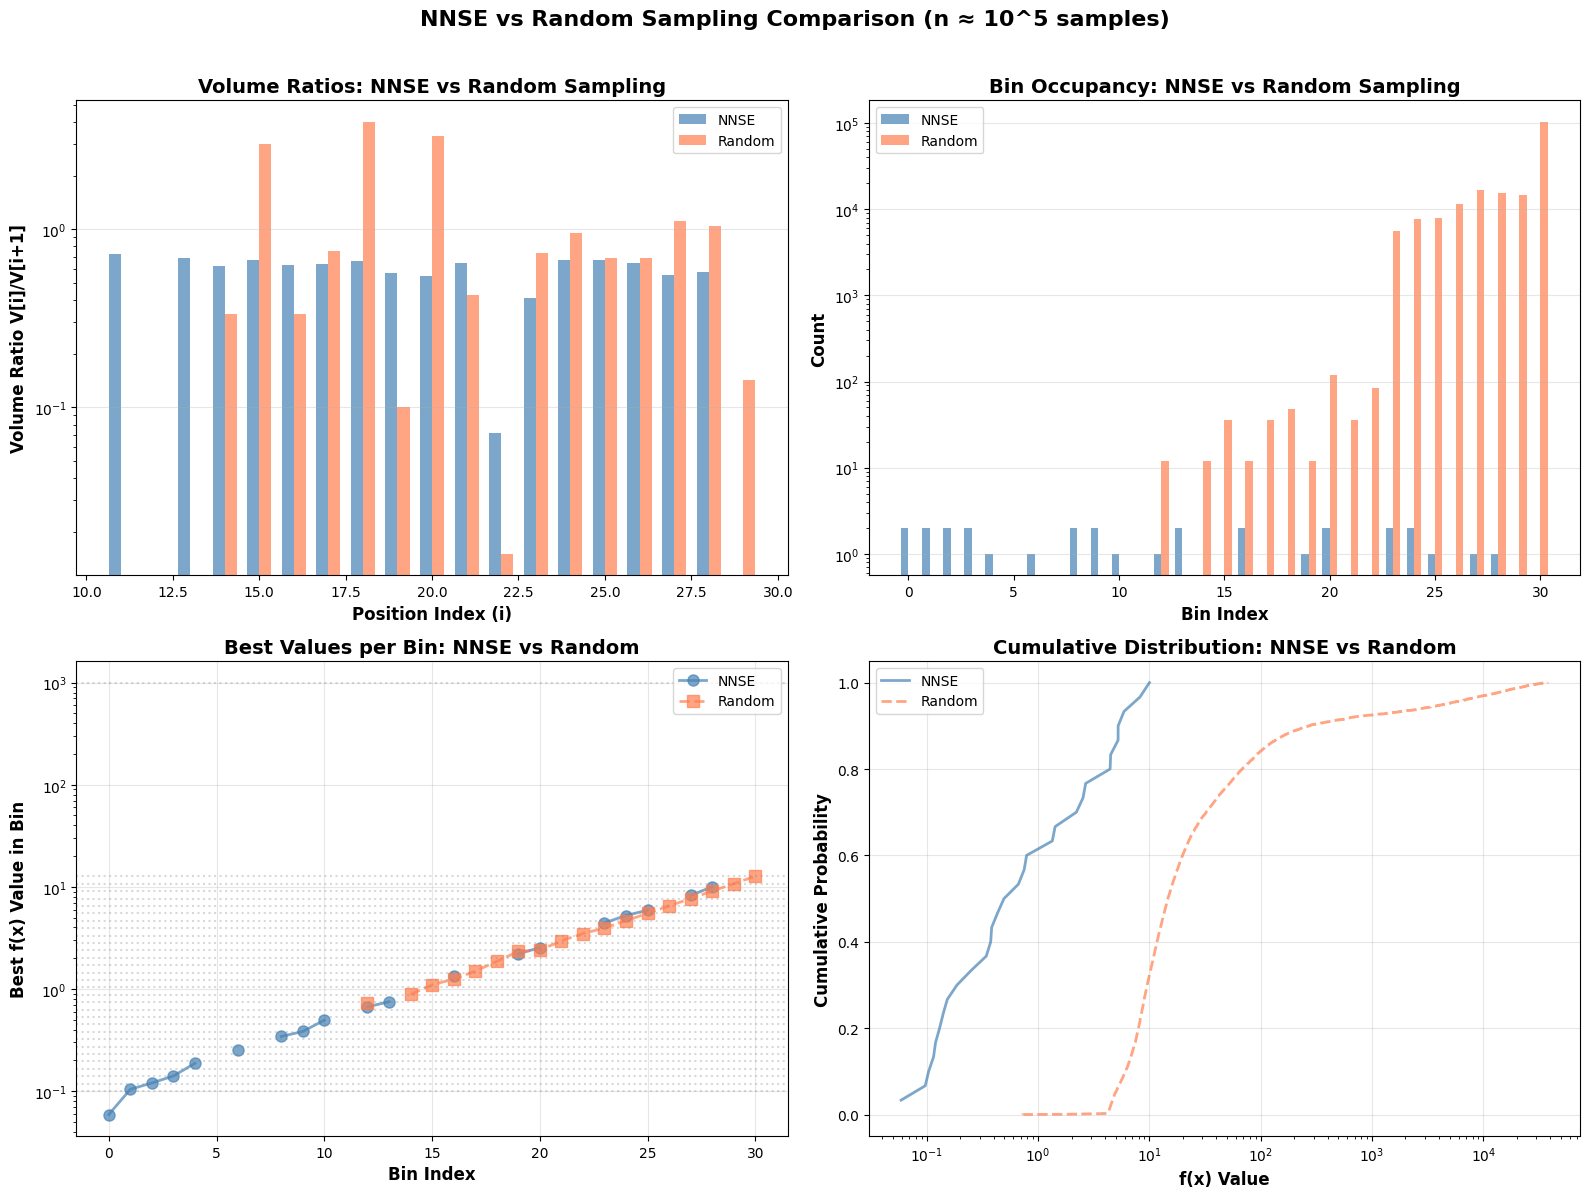


✓ Random sampling comparison complete
  NNSE improvement: 12.35x better best value


In [ ]:

# ============================================================================
# === 2x2 COMPARISON PLOT ===
# ============================================================================

# Calculate number of samples in 10^n format
log10_samples = np.log10(n_total_samples)
rounded_exponent = int(np.round(log10_samples))

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Add overall title with sample count
fig.suptitle(f'NNSE vs Random Sampling Comparison (n ≈ 10^{rounded_exponent} samples)', 
             fontsize=16, fontweight='bold', y=0.995)

# Plot 1: Volume ratios comparison
ax1 = axes[0, 0]
positions = np.arange(N_Vec)
width = 0.35

# Filter out positions with valid data for both
valid_mask = np.isfinite(nnse_volume_ratios[1:]) & np.isfinite(random_volume_ratios)
positions_valid = positions[valid_mask]

if len(positions_valid) > 0:
    ax1.bar(positions_valid - width/2, nnse_volume_ratios[1:][valid_mask], width, 
            label='NNSE', alpha=0.7, color='steelblue')
    ax1.bar(positions_valid + width/2, random_volume_ratios[valid_mask], width,
            label='Random', alpha=0.7, color='coral')
else:
    # Fall back to all positions if filtering is too strict
    ax1.bar(positions - width/2, nnse_volume_ratios[1:], width, 
            label='NNSE', alpha=0.7, color='steelblue')
    ax1.bar(positions + width/2, random_volume_ratios, width,
            label='Random', alpha=0.7, color='coral')

ax1.set_xlabel('Position Index (i)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Volume Ratio V[i]/V[i+1]', fontsize=12, fontweight='bold')
ax1.set_title('Volume Ratios: NNSE vs Random Sampling', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_yscale('log')

# Plot 2: Bin counts comparison
ax2 = axes[0, 1]
bin_indices = np.arange(N_Vec + 1)
ax2.bar(bin_indices - width/2, nnse_bin_counts, width,
        label='NNSE', alpha=0.7, color='steelblue')
ax2.bar(bin_indices + width/2, random_bin_counts, width,
        label='Random', alpha=0.7, color='coral')
ax2.set_xlabel('Bin Index', fontsize=12, fontweight='bold')
ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
ax2.set_title('Bin Occupancy: NNSE vs Random Sampling', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_yscale('log')

# Plot 3: Best values per bin
ax3 = axes[1, 0]
nnse_best_per_bin = []
for i in range(N_Vec + 1):
    # Find best value in NNSE results for bin i
    best_val = np.inf
    for j, fx in enumerate(fX_list):
        if fx is not None and np.isfinite(fx):
            # Check if this belongs to bin i
            bin_idx = N_Vec
            for k in range(N_Vec + 1):
                if fx <= bin_thresholds[k]:
                    bin_idx = k
                    break
            if bin_idx == i and fx < best_val:
                best_val = fx
    nnse_best_per_bin.append(best_val if best_val != np.inf else np.nan)

nnse_best_per_bin = np.array(nnse_best_per_bin)

# Plot best values per bin
valid_bins = ~np.isnan(nnse_best_per_bin) | ~np.isinf(random_best_fX_per_bin)
ax3.semilogy(bin_indices, nnse_best_per_bin, 'o-', label='NNSE', 
             markersize=8, linewidth=2, alpha=0.7, color='steelblue')
ax3.semilogy(bin_indices, random_best_fX_per_bin, 's--', label='Random', 
             markersize=8, linewidth=2, alpha=0.7, color='coral')
# Draw horizontal lines for bin thresholds
for threshold in bin_thresholds:
    ax3.axhline(y=threshold, color='gray', linestyle=':', alpha=0.3)
ax3.set_xlabel('Bin Index', fontsize=12, fontweight='bold')
ax3.set_ylabel('Best f(x) Value in Bin', fontsize=12, fontweight='bold')
ax3.set_title('Best Values per Bin: NNSE vs Random', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# Plot 4: Cumulative distribution of f(x) values
ax4 = axes[1, 1]
nnse_fX_valid = [fx for fx in fX_list if fx is not None and np.isfinite(fx)]
nnse_fX_sorted = np.sort(nnse_fX_valid)
random_fX_sorted = np.sort(random_fX)

# Create cumulative distribution
nnse_cumulative = np.arange(1, len(nnse_fX_sorted) + 1) / len(nnse_fX_sorted)
random_cumulative = np.arange(1, len(random_fX_sorted) + 1) / len(random_fX_sorted)

ax4.semilogx(nnse_fX_sorted, nnse_cumulative, '-', label='NNSE', 
             linewidth=2, alpha=0.7, color='steelblue')
ax4.semilogx(random_fX_sorted, random_cumulative, '--', label='Random', 
             linewidth=2, alpha=0.7, color='coral')
ax4.set_xlabel('f(x) Value', fontsize=12, fontweight='bold')
ax4.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax4.set_title('Cumulative Distribution: NNSE vs Random', fontsize=14, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.98])  # Leave space for suptitle
plt.show()

print(f"\n✓ Random sampling comparison complete")
print(f"  NNSE improvement: {random_fX.min() / np.nanmin(nnse_fX_valid):.2f}x better best value")



CUMULATIVE VOLUME ESTIMATES FROM NNSE

Cumulative volumes (normalized relative to total volume = 1.0):
  V[0]/V_total = 3.491464e-07
  V[1]/V_total = 4.879848e-07
  V[2]/V_total = 6.729988e-07
  V[3]/V_total = 1.028639e-06
  V[4]/V_total = 1.421774e-06
  V[5]/V_total = 2.243064e-06
  V[6]/V_total = 3.174076e-06
  V[7]/V_total = 4.343930e-06
  V[8]/V_total = 6.359391e-06
  V[9]/V_total = 9.403620e-06
  V[10]/V_total = 1.455086e-05
  V[11]/V_total = 2.089805e-05
  V[12]/V_total = 2.898126e-05
  V[13]/V_total = 4.295621e-05
  V[14]/V_total = 6.237511e-05
  V[15]/V_total = 9.985612e-05
  V[16]/V_total = 1.488017e-04
  V[17]/V_total = 2.376073e-04
  V[18]/V_total = 3.732122e-04
  V[19]/V_total = 5.603153e-04
  V[20]/V_total = 9.845978e-04
  V[21]/V_total = 1.792276e-03
  V[22]/V_total = 2.759161e-03
  V[23]/V_total = 3.824706e-02
  V[24]/V_total = 9.281137e-02
  V[25]/V_total = 1.381932e-01
  V[26]/V_total = 2.049100e-01
  V[27]/V_total = 3.172103e-01
  V[28]/V_total = 5.750300e-01
  V[29]

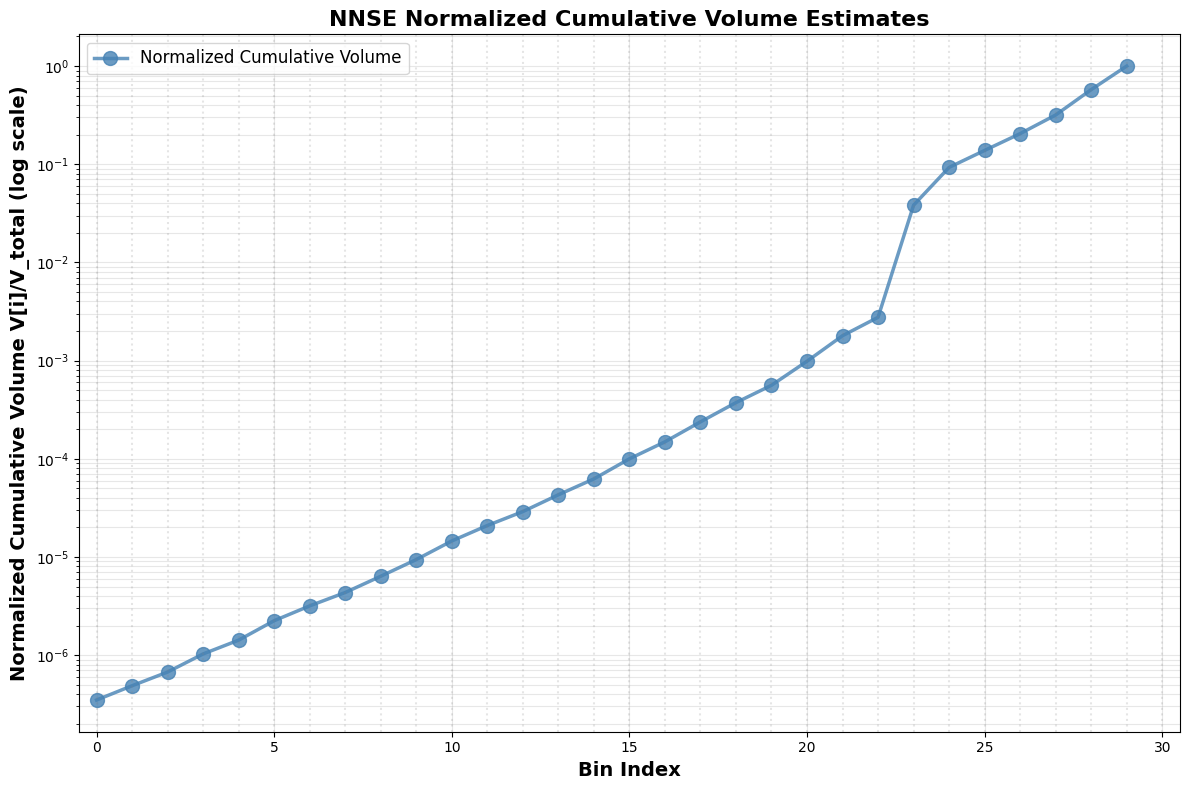


✓ Cumulative volume plot complete
  Total volume (last bin): V_total = 2.864128e+06


In [ ]:
# ============================================================================
# === CUMULATIVE VOLUME ESTIMATES (NNSE) ===
# ============================================================================

print("\n" + "="*80)
print("CUMULATIVE VOLUME ESTIMATES FROM NNSE")
print("="*80)

# Compute cumulative volumes from volume ratios
# volume_ratios[i] = V[i-1]/V[i], so V[i] = V[i-1] / volume_ratios[i]
# Starting with V[0] = 1 (normalized), we get:
# V[i] = 1 / (product of volume_ratios[1] through volume_ratios[i])

cumulative_volumes = np.zeros(N_Vec + 1)
cumulative_volumes[0] = 1.0  # V[0] normalized to 1

for i in range(1, N_Vec + 1):
    if i == 1:
        # Special case: volume_ratios[0] is not used in NNSE (it's position 0)
        # volume_ratios[1] = V[0]/V[1]
        if volume_ratios[i] > 0:
            cumulative_volumes[i] = cumulative_volumes[i-1] / volume_ratios[i]
        else:
            cumulative_volumes[i] = np.nan
    else:
        if volume_ratios[i] > 0:
            cumulative_volumes[i] = cumulative_volumes[i-1] / volume_ratios[i]
        else:
            cumulative_volumes[i] = np.nan

# Normalize relative to total volume (last bin)
total_volume = cumulative_volumes[-1] if np.isfinite(cumulative_volumes[-1]) else np.nanmax(cumulative_volumes)
cumulative_volumes_normalized = cumulative_volumes / total_volume

print(f"\nCumulative volumes (normalized relative to total volume = 1.0):")
for i in range(N_Vec + 1):
    if np.isfinite(cumulative_volumes_normalized[i]):
        print(f"  V[{i}]/V_total = {cumulative_volumes_normalized[i]:.6e}")
    else:
        print(f"  V[{i}]/V_total = undefined")

# Plot normalized cumulative volumes
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

bin_indices = np.arange(N_Vec + 1)
valid_volumes = np.isfinite(cumulative_volumes_normalized)

ax.semilogy(bin_indices[valid_volumes], cumulative_volumes_normalized[valid_volumes], 
            'o-', markersize=10, linewidth=2.5, alpha=0.8, color='steelblue',
            label='Normalized Cumulative Volume')

# Add bin thresholds as vertical reference lines
for i, threshold in enumerate(bin_thresholds):
    ax.axvline(x=i, color='gray', linestyle=':', alpha=0.2)

ax.set_xlabel('Bin Index', fontsize=14, fontweight='bold')
ax.set_ylabel('Normalized Cumulative Volume V[i]/V_total (log scale)', fontsize=14, fontweight='bold')
ax.set_title('NNSE Normalized Cumulative Volume Estimates', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, which='both')
ax.set_xlim(-0.5, N_Vec + 0.5)

plt.tight_layout()

# Save figure to folder
import os
from datetime import datetime

# Create figures directory if it doesn't exist
figures_dir = "NNSE_figures"
os.makedirs(figures_dir, exist_ok=True)

# Generate filename with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"cumulative_volumes_{timestamp}.png"
filepath = os.path.join(figures_dir, filename)

# Save figure with high DPI
fig.savefig(filepath, dpi=300, bbox_inches='tight')
print(f"\n✓ Figure saved to: {filepath}")

plt.show()

print(f"\n✓ Cumulative volume plot complete")
print(f"  Total volume (last bin): V_total = {total_volume:.6e}")



VOLUME RATIO CONVERGENCE ANALYSIS
Analyzing volume ratio convergence over 39 timepoints...


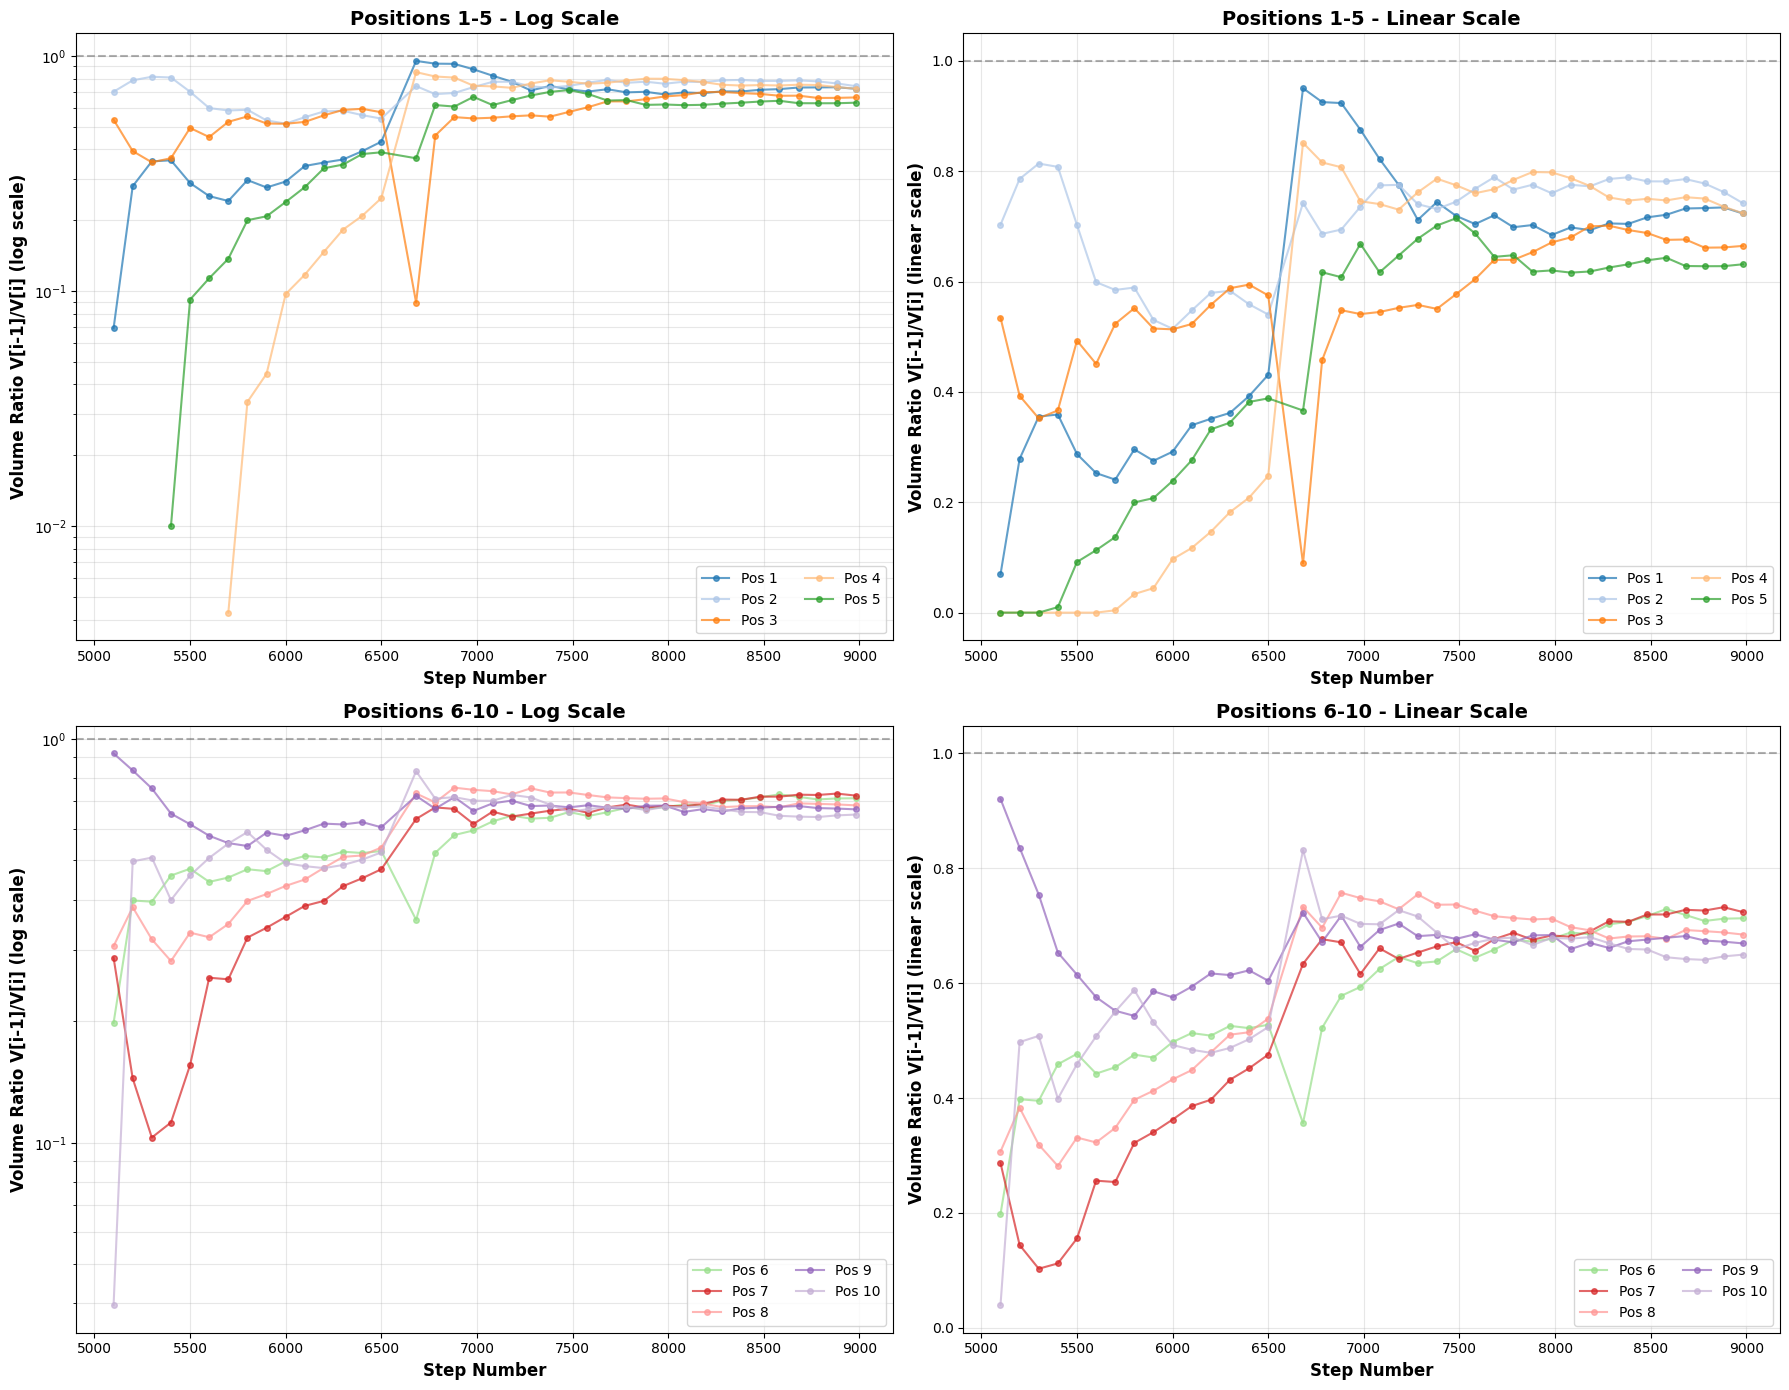


✓ Volume ratio convergence visualization complete
  Number of timepoints tracked: 39

Convergence statistics (last 5 timepoints):
  Position 1: mean=0.7290, std=0.0055, CV=0.0076
  Position 2: mean=0.7699, std=0.0160, CV=0.0208
  Position 3: mean=0.6680, std=0.0066, CV=0.0099
  Position 4: mean=0.7421, std=0.0108, CV=0.0146
  Position 5: mean=0.6317, std=0.0059, CV=0.0093
  Position 6: mean=0.7163, std=0.0072, CV=0.0101
  Position 7: mean=0.7260, std=0.0042, CV=0.0058
  Position 8: mean=0.6867, std=0.0054, CV=0.0079
  Position 9: mean=0.6754, std=0.0046, CV=0.0068
  Position 10: mean=0.6449, std=0.0033, CV=0.0050


In [ ]:
# ============================================================================
# === VOLUME RATIO CONVERGENCE DURING BURN-IN ===
# ============================================================================

print("\n" + "="*80)
print("VOLUME RATIO CONVERGENCE ANALYSIS")
print("="*80)

if len(volume_ratio_history) > 0:
    print(f"Analyzing volume ratio convergence over {len(volume_ratio_history)} timepoints...")
    
    # Extract steps and ratios for each position
    steps_history = [item[0] for item in volume_ratio_history]
    
    # Use a color map for different positions
    colors = plt.cm.tab20(np.linspace(0, 1, min(N_Vec, 20)))
    
    # Create 2x2 plot
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    
    # Define which positions to plot in each subplot
    positions_sets = [
        (range(1, 6), "Positions 1-5"),    # Top left & right
        (range(6, 11), "Positions 6-10")   # Bottom left & right
    ]
    
    for row_idx, (position_range, label) in enumerate(positions_sets):
        # Log scale (left column)
        ax_log = axes[row_idx, 0]
        # Linear scale (right column)
        ax_lin = axes[row_idx, 1]
        
        for i in position_range:
            if i > N_Vec:
                break
            ratios_over_time = [item[1][i] for item in volume_ratio_history if i < len(item[1])]
            if len(ratios_over_time) > 0:
                # For log scale: filter out non-positive values
                valid_indices_log = [j for j, r in enumerate(ratios_over_time) if r > 0]
                if valid_indices_log:
                    steps_valid_log = [steps_history[j] for j in valid_indices_log]
                    ratios_valid_log = [ratios_over_time[j] for j in valid_indices_log]
                    ax_log.plot(steps_valid_log, ratios_valid_log, 
                               marker='o', markersize=4, linewidth=1.5, alpha=0.7,
                               color=colors[(i-1) % len(colors)],
                               label=f'Pos {i}')
                
                # For linear scale: use all values
                ax_lin.plot(steps_history[:len(ratios_over_time)], ratios_over_time, 
                           marker='o', markersize=4, linewidth=1.5, alpha=0.7,
                           color=colors[(i-1) % len(colors)],
                           label=f'Pos {i}')
        
        # Configure log scale plot (left column)
        ax_log.set_xlabel('Step Number', fontsize=12, fontweight='bold')
        ax_log.set_ylabel('Volume Ratio V[i-1]/V[i] (log scale)', fontsize=12, fontweight='bold')
        ax_log.set_title(f'{label} - Log Scale', fontsize=14, fontweight='bold')
        ax_log.set_yscale('log')
        ax_log.legend(fontsize=10, loc='best', ncol=2)
        ax_log.grid(True, alpha=0.3, which='both')
        ax_log.axhline(y=1.0, color='black', linestyle='--', alpha=0.3, linewidth=1.5)
        
        # Configure linear scale plot (right column)
        ax_lin.set_xlabel('Step Number', fontsize=12, fontweight='bold')
        ax_lin.set_ylabel('Volume Ratio V[i-1]/V[i] (linear scale)', fontsize=12, fontweight='bold')
        ax_lin.set_title(f'{label} - Linear Scale', fontsize=14, fontweight='bold')
        ax_lin.legend(fontsize=10, loc='best', ncol=2)
        ax_lin.grid(True, alpha=0.3)
        ax_lin.axhline(y=1.0, color='black', linestyle='--', alpha=0.3, linewidth=1.5)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Volume ratio convergence visualization complete")
    print(f"  Number of timepoints tracked: {len(volume_ratio_history)}")
    
    # Compute convergence statistics
    print(f"\nConvergence statistics (last 5 timepoints):")
    for i in range(1, min(11, N_Vec + 1)):
        ratios_over_time = [item[1][i] for item in volume_ratio_history if i < len(item[1])]
        if len(ratios_over_time) >= 5:
            recent_ratios = ratios_over_time[-5:]
            mean_recent = np.mean(recent_ratios)
            std_recent = np.std(recent_ratios)
            cv_recent = std_recent / mean_recent if mean_recent > 0 else np.nan
            print(f"  Position {i}: mean={mean_recent:.4f}, std={std_recent:.4f}, CV={cv_recent:.4f}")
else:
    print("No volume ratio history available for convergence analysis.")


Preparing data for visualization...
  Total steps: 9082
  Steps with valid data: 9082
  First valid step: 0
  Best f value trajectory: 9082 points

Computing PCA for trajectory visualization...
✓ PCA complete
  Explained variance ratio: [0.64047238 0.2154528  0.08990401]
  Total explained variance: 0.9458
Simulating with first and last parameters...
✓ Simulations complete


/tmp/ipykernel_2716696/2323879531.py:137: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


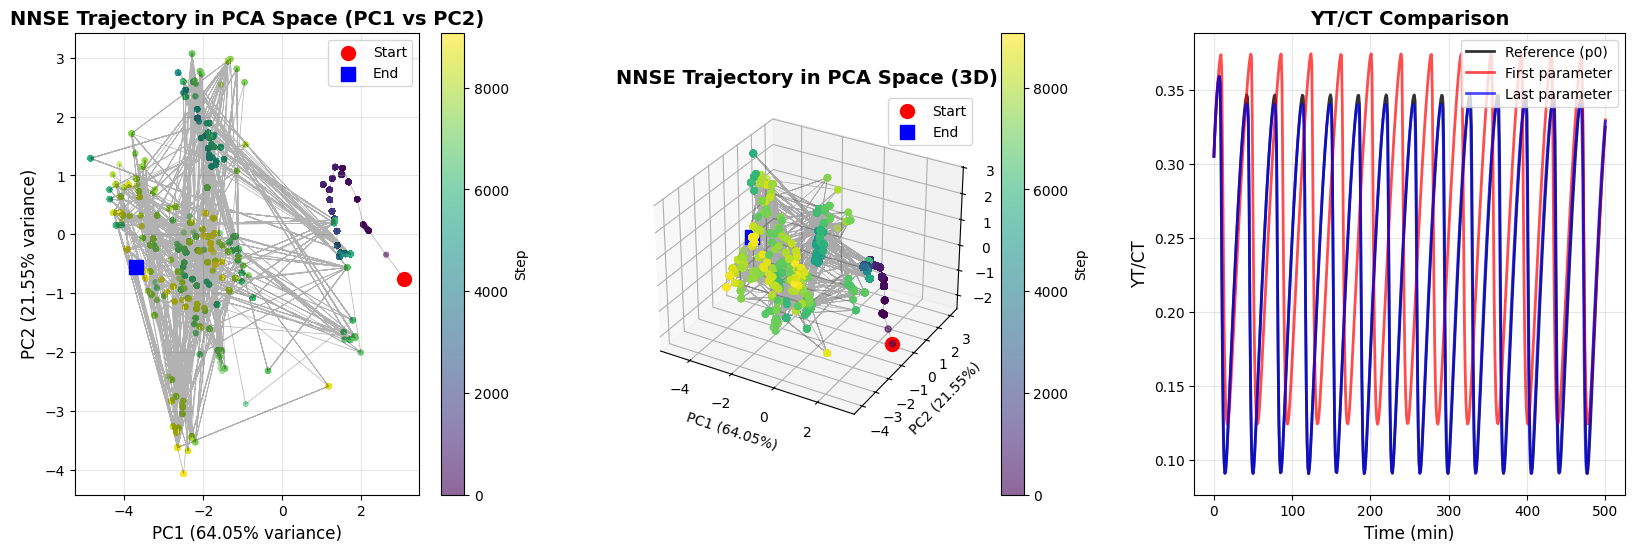


Plotting distribution of squared differences...
  Valid values: 183389/272460
  Mean: 2.553391e+00
  Median: 8.462484e-01
  Min: 9.801897e-03
  Max: 1.269044e+01


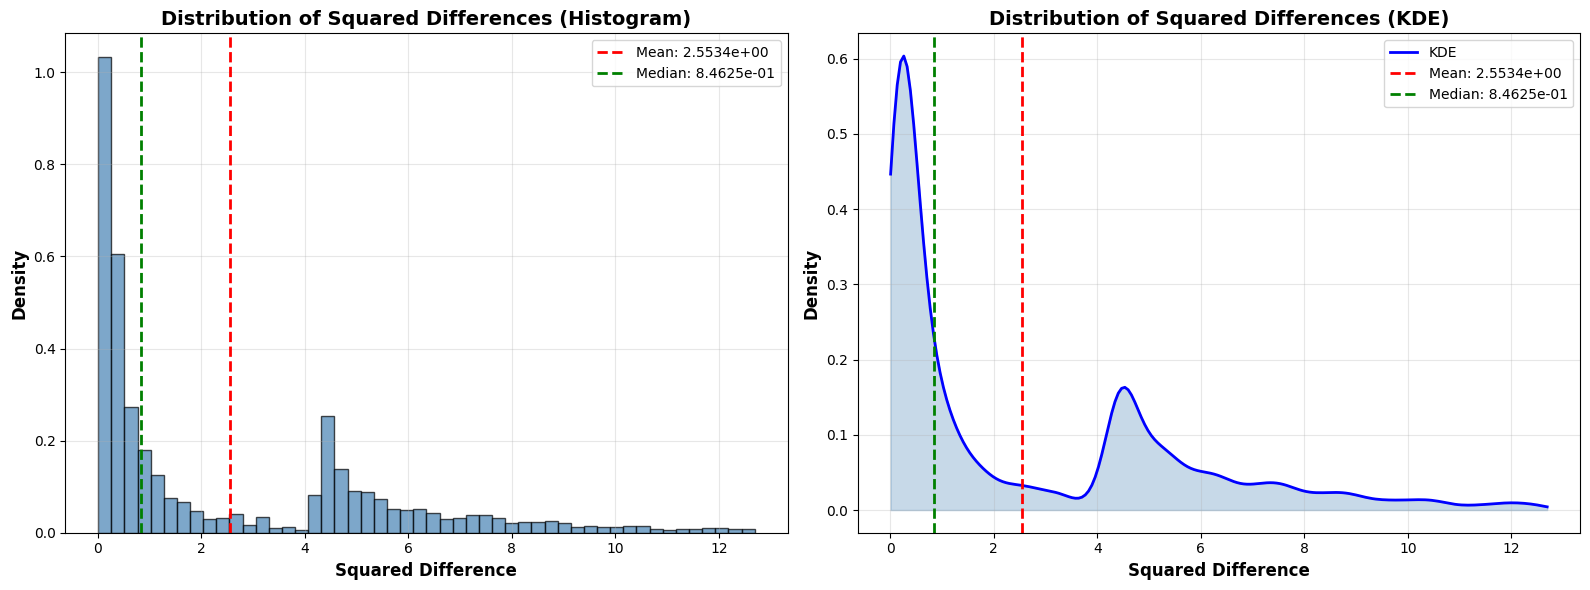

✓ Visualization complete


In [ ]:
# ============================================================================
# === VISUALIZATION: PCA TRAJECTORY AND DISTRIBUTIONS ===
# ============================================================================

from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde

print("Preparing data for visualization...")

# Convert to numpy arrays, handling None values
# For X: use np.nan where None, for fX: use np.nan where None
all_X_array = np.array([[x if x is not None else np.nan * np.ones(n_params) for x in step_X] for step_X in all_X])
all_fX_array = np.array([[fx if fx is not None else np.nan for fx in step_fX] for step_fX in all_fX])

# Extract the best vector at each step
# Since vectors are sorted by f value, find the first non-NaN value (best available)
# This handles the case where x0 might be empty for many steps
trajectory = []
squared_diffs = []
step_indices = []  # Keep track of which steps had valid data

for step_idx in range(len(all_X_array)):
    # Find the first non-NaN (best) vector at this step
    for pos_idx in range(n):
        if not np.isnan(all_fX_array[step_idx, pos_idx]):
            trajectory.append(all_X_array[step_idx, pos_idx])
            squared_diffs.append(all_fX_array[step_idx, pos_idx])
            step_indices.append(step_idx)
            break  # Found the best available vector, move to next step

trajectory = np.array(trajectory)
squared_diffs = np.array(squared_diffs)
step_indices = np.array(step_indices)

print(f"  Total steps: {len(all_X_array)}")
print(f"  Steps with valid data: {len(trajectory)}")
print(f"  First valid step: {step_indices[0] if len(step_indices) > 0 else 'None'}")
print(f"  Best f value trajectory: {len(squared_diffs)} points")

# ============================================================================
# === PCA TRAJECTORY PLOT ===
# ============================================================================

print("\nComputing PCA for trajectory visualization...")

# Normalize trajectory for PCA (use standardized parameters)
trajectory_normalized = (trajectory - trajectory.mean(axis=0)) / (trajectory.std(axis=0) + 1e-10)

# Compute PCA
pca = PCA(n_components=min(3, n_params))
trajectory_pca = pca.fit_transform(trajectory_normalized)

print(f"✓ PCA complete")
print(f"  Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"  Total explained variance: {np.sum(pca.explained_variance_ratio_):.4f}")

# Simulate with first and last parameters for YT/CT comparison
print("Simulating with first and last parameters...")
P_first = trajectory[0]  # Best parameter vector at step 0
P_last = trajectory[-1]  # Best parameter vector at final step

# Convert to parameter dictionaries
p_first = copy.deepcopy(p0)
p_last = copy.deepcopy(p0)
for i, name in enumerate(param_names):
    p_first[name] = P_first[i]
    p_last[name] = P_last[i]

# Simulate
t_first, y_first = simulate_at_params(p_first, t_eval)
YT_first, M_first = compute_obs(y_first)
t_last, y_last = simulate_at_params(p_last, t_eval)
YT_last, M_last = compute_obs(y_last)

print("✓ Simulations complete")

# Create figure with 3 subplots
fig = plt.figure(figsize=(20, 6))
gs = fig.add_gridspec(1, 3, hspace=0.3, wspace=0.3)

# Plot 2D PCA trajectory
ax1 = fig.add_subplot(gs[0, 0])
scatter = ax1.scatter(trajectory_pca[:, 0], trajectory_pca[:, 1], 
                     c=range(len(trajectory_pca)), cmap='viridis', 
                     s=20, alpha=0.6, edgecolors='none')
ax1.plot(trajectory_pca[:, 0], trajectory_pca[:, 1], 'k-', alpha=0.3, linewidth=0.5)
ax1.scatter(trajectory_pca[0, 0], trajectory_pca[0, 1], 
           color='red', s=100, marker='o', label='Start', zorder=5)
ax1.scatter(trajectory_pca[-1, 0], trajectory_pca[-1, 1], 
           color='blue', s=100, marker='s', label='End', zorder=5)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
ax1.set_title('NNSE Trajectory in PCA Space (PC1 vs PC2)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax1, label='Step')

# Second subplot: 3D plot or squared difference over time
if trajectory_pca.shape[1] >= 3:
    from mpl_toolkits.mplot3d import Axes3D
    ax2 = fig.add_subplot(gs[0, 1], projection='3d')
    scatter2 = ax2.scatter(trajectory_pca[:, 0], trajectory_pca[:, 1], trajectory_pca[:, 2],
                         c=range(len(trajectory_pca)), cmap='viridis', s=20, alpha=0.6)
    ax2.plot(trajectory_pca[:, 0], trajectory_pca[:, 1], trajectory_pca[:, 2], 
            'k-', alpha=0.3, linewidth=0.5)
    ax2.scatter(trajectory_pca[0, 0], trajectory_pca[0, 1], trajectory_pca[0, 2],
               color='red', s=100, marker='o', label='Start')
    ax2.scatter(trajectory_pca[-1, 0], trajectory_pca[-1, 1], trajectory_pca[-1, 2],
               color='blue', s=100, marker='s', label='End')
    ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=10)
    ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=10)
    ax2.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%})', fontsize=10)
    ax2.set_title('NNSE Trajectory in PCA Space (3D)', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    plt.colorbar(scatter2, ax=ax2, label='Step')
else:
    # If only 2 components, show squared difference over time
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(range(len(squared_diffs)), squared_diffs, 'b-', linewidth=1, alpha=0.7)
    ax2.set_xlabel('Step', fontsize=12)
    ax2.set_ylabel('Squared Difference', fontsize=12)
    ax2.set_title('Best Squared Difference Over Time', fontsize=14, fontweight='bold')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)

# Third subplot: YT/CT comparison
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(t0, YT0, 'k-', lw=2, label='Reference (p0)', alpha=0.8)
ax3.plot(t_first, YT_first, 'r-', lw=2, label='First parameter', alpha=0.7)
ax3.plot(t_last, YT_last, 'b-', lw=2, label='Last parameter', alpha=0.7)
ax3.set_xlabel('Time (min)', fontsize=12)
ax3.set_ylabel('YT/CT', fontsize=12)
ax3.set_title('YT/CT Comparison', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# === DISTRIBUTION OF SQUARED DIFFERENCES ===
# ============================================================================

print("\nPlotting distribution of squared differences...")

# For distribution, use all squared differences from all vectors at all steps
# This gives a better picture of the full distribution
squared_diffs_all = all_fX_array.flatten()  # All function values from all vectors

# Filter out infinite values
valid_mask = np.isfinite(squared_diffs_all)
squared_diffs_valid = squared_diffs_all[valid_mask]

print(f"  Valid values: {np.sum(valid_mask)}/{len(squared_diffs_all)}")
print(f"  Mean: {np.mean(squared_diffs_valid):.6e}")
print(f"  Median: {np.median(squared_diffs_valid):.6e}")
print(f"  Min: {np.min(squared_diffs_valid):.6e}")
print(f"  Max: {np.max(squared_diffs_valid):.6e}")

# Create distribution plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram with linear bins
ax1 = axes[0]
n_bins_hist = 50
# Use linear bins from min to max
counts, bins_hist, patches = ax1.hist(squared_diffs_valid, bins=n_bins_hist, 
                                      edgecolor='black', alpha=0.7, color='steelblue',
                                      density=True)
ax1.axvline(np.mean(squared_diffs_valid), color='red', linestyle='--', 
           linewidth=2, label=f'Mean: {np.mean(squared_diffs_valid):.4e}')
ax1.axvline(np.median(squared_diffs_valid), color='green', linestyle='--', 
           linewidth=2, label=f'Median: {np.median(squared_diffs_valid):.4e}')
ax1.set_xlabel('Squared Difference', fontsize=12, fontweight='bold')
ax1.set_ylabel('Density', fontsize=12, fontweight='bold')
ax1.set_title('Distribution of Squared Differences (Histogram)', 
             fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Kernel density estimate (KDE) with linear scale
ax2 = axes[1]
if len(squared_diffs_valid) > 1:
    # Use linear KDE (not log-transformed)
    kde = gaussian_kde(squared_diffs_valid)
    x_kde = np.linspace(squared_diffs_valid.min(), squared_diffs_valid.max(), 200)
    density = kde(x_kde)
    ax2.plot(x_kde, density, 'b-', linewidth=2, label='KDE')
    ax2.fill_between(x_kde, 0, density, alpha=0.3, color='steelblue')
    ax2.axvline(np.mean(squared_diffs_valid), color='red', linestyle='--', 
               linewidth=2, label=f'Mean: {np.mean(squared_diffs_valid):.4e}')
    ax2.axvline(np.median(squared_diffs_valid), color='green', linestyle='--', 
               linewidth=2, label=f'Median: {np.median(squared_diffs_valid):.4e}')
    ax2.set_xlabel('Squared Difference', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Density', fontsize=12, fontweight='bold')
    ax2.set_title('Distribution of Squared Differences (KDE)', 
                 fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'Not enough data for KDE', 
            ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    ax2.set_title('Distribution of Squared Differences (KDE)', 
                 fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Visualization complete")



Extracting trajectory for y0 bin only (true best)...
  Total steps with y0 filled: 7763
  First y0 step: 1319
  Last y0 step: 9081
  Y0 squared differences range: [0.0098, 0.1000]
✓ PCA complete for y0 trajectory
  Explained variance ratio: [0.64677126 0.21095121 0.09728382]
  Total explained variance: 0.9550
Simulating with first and last y0 parameters...
✓ Simulations complete


/tmp/ipykernel_2716696/352128864.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


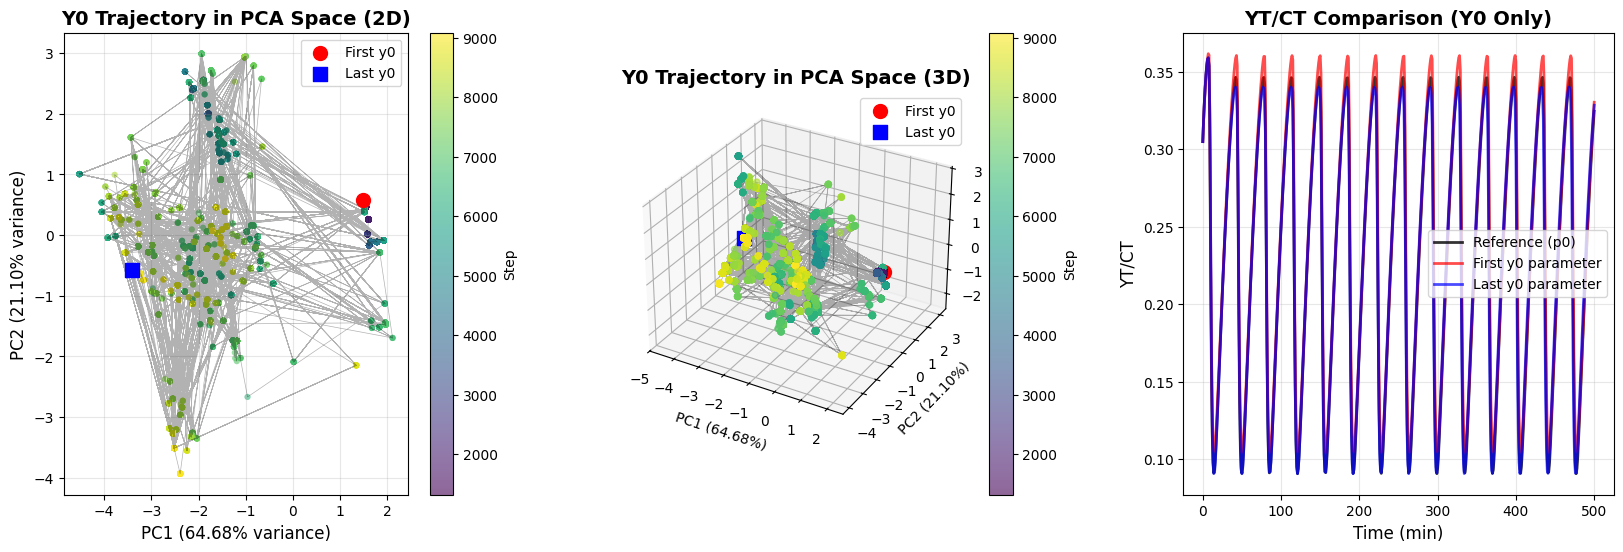

✓ Y0-only visualization complete


In [ ]:
# ============================================================================
# === PCA TRAJECTORY FOR Y0 BIN ONLY (TRUE BEST) ===
# ============================================================================

print("\nExtracting trajectory for y0 bin only (true best)...")

# Extract only the points where position 0 (y0 bin) is filled
trajectory_y0 = []
squared_diffs_y0 = []
step_indices_y0 = []

for step_idx in range(len(all_X_array)):
    # Only include steps where position 0 is filled (not NaN)
    if not np.isnan(all_fX_array[step_idx, 0]):
        trajectory_y0.append(all_X_array[step_idx, 0])
        squared_diffs_y0.append(all_fX_array[step_idx, 0])
        step_indices_y0.append(step_idx)

if len(trajectory_y0) > 0:
    trajectory_y0 = np.array(trajectory_y0)
    squared_diffs_y0 = np.array(squared_diffs_y0)
    step_indices_y0 = np.array(step_indices_y0)
    
    print(f"  Total steps with y0 filled: {len(trajectory_y0)}")
    print(f"  First y0 step: {step_indices_y0[0]}")
    print(f"  Last y0 step: {step_indices_y0[-1]}")
    print(f"  Y0 squared differences range: [{squared_diffs_y0.min():.4f}, {squared_diffs_y0.max():.4f}]")
    
    # Normalize trajectory for PCA
    trajectory_y0_normalized = (trajectory_y0 - trajectory_y0.mean(axis=0)) / (trajectory_y0.std(axis=0) + 1e-10)
    
    # Compute PCA
    pca_y0 = PCA(n_components=min(3, n_params))
    trajectory_y0_pca = pca_y0.fit_transform(trajectory_y0_normalized)
    
    print(f"✓ PCA complete for y0 trajectory")
    print(f"  Explained variance ratio: {pca_y0.explained_variance_ratio_}")
    print(f"  Total explained variance: {np.sum(pca_y0.explained_variance_ratio_):.4f}")
    
    # Simulate with first and last y0 parameters
    print("Simulating with first and last y0 parameters...")
    P_first_y0 = trajectory_y0[0]
    P_last_y0 = trajectory_y0[-1]
    
    p_first_y0 = copy.deepcopy(p0)
    p_last_y0 = copy.deepcopy(p0)
    for i, name in enumerate(param_names):
        p_first_y0[name] = P_first_y0[i]
        p_last_y0[name] = P_last_y0[i]
    
    t_first_y0, y_first_y0 = simulate_at_params(p_first_y0, t_eval)
    YT_first_y0, M_first_y0 = compute_obs(y_first_y0)
    t_last_y0, y_last_y0 = simulate_at_params(p_last_y0, t_eval)
    YT_last_y0, M_last_y0 = compute_obs(y_last_y0)
    
    print("✓ Simulations complete")
    
    # Create figure with 3 subplots for y0 trajectory
    fig_y0 = plt.figure(figsize=(20, 6))
    gs_y0 = fig_y0.add_gridspec(1, 3, hspace=0.3, wspace=0.3)
    
    # Plot 2D PCA trajectory for y0
    ax1_y0 = fig_y0.add_subplot(gs_y0[0, 0])
    scatter_y0 = ax1_y0.scatter(trajectory_y0_pca[:, 0], trajectory_y0_pca[:, 1], 
                         c=step_indices_y0, cmap='viridis', 
                         s=20, alpha=0.6, edgecolors='none')
    ax1_y0.plot(trajectory_y0_pca[:, 0], trajectory_y0_pca[:, 1], 'k-', alpha=0.3, linewidth=0.5)
    ax1_y0.scatter(trajectory_y0_pca[0, 0], trajectory_y0_pca[0, 1], 
               color='red', s=100, marker='o', label='First y0', zorder=5)
    ax1_y0.scatter(trajectory_y0_pca[-1, 0], trajectory_y0_pca[-1, 1], 
               color='blue', s=100, marker='s', label='Last y0', zorder=5)
    ax1_y0.set_xlabel(f'PC1 ({pca_y0.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
    ax1_y0.set_ylabel(f'PC2 ({pca_y0.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
    ax1_y0.set_title('Y0 Trajectory in PCA Space (2D)', fontsize=14, fontweight='bold')
    ax1_y0.legend(fontsize=10)
    plt.colorbar(scatter_y0, ax=ax1_y0, label='Step')
    ax1_y0.grid(True, alpha=0.3)
    
    # Second subplot: 3D or squared difference over time
    if pca_y0.n_components >= 3:
        ax2_y0 = fig_y0.add_subplot(gs_y0[0, 1], projection='3d')
        scatter2_y0 = ax2_y0.scatter(trajectory_y0_pca[:, 0], trajectory_y0_pca[:, 1], trajectory_y0_pca[:, 2],
                       c=step_indices_y0, cmap='viridis', s=20, alpha=0.6)
        ax2_y0.plot(trajectory_y0_pca[:, 0], trajectory_y0_pca[:, 1], trajectory_y0_pca[:, 2],
                   'k-', alpha=0.3, linewidth=0.5)
        ax2_y0.scatter(trajectory_y0_pca[0, 0], trajectory_y0_pca[0, 1], trajectory_y0_pca[0, 2],
                   color='red', s=100, marker='o', label='First y0')
        ax2_y0.scatter(trajectory_y0_pca[-1, 0], trajectory_y0_pca[-1, 1], trajectory_y0_pca[-1, 2],
                   color='blue', s=100, marker='s', label='Last y0')
        ax2_y0.set_xlabel(f'PC1 ({pca_y0.explained_variance_ratio_[0]:.2%})', fontsize=10)
        ax2_y0.set_ylabel(f'PC2 ({pca_y0.explained_variance_ratio_[1]:.2%})', fontsize=10)
        ax2_y0.set_zlabel(f'PC3 ({pca_y0.explained_variance_ratio_[2]:.2%})', fontsize=10)
        ax2_y0.set_title('Y0 Trajectory in PCA Space (3D)', fontsize=14, fontweight='bold')
        ax2_y0.legend(fontsize=10)
        plt.colorbar(scatter2_y0, ax=ax2_y0, label='Step')
    else:
        # If only 2 components, show squared difference over time for y0
        ax2_y0 = fig_y0.add_subplot(gs_y0[0, 1])
        ax2_y0.plot(step_indices_y0, squared_diffs_y0, 'b-', linewidth=1, alpha=0.7)
        ax2_y0.set_xlabel('Step', fontsize=12)
        ax2_y0.set_ylabel('Squared Difference (Y0)', fontsize=12)
        ax2_y0.set_title('Y0 Squared Difference Over Time', fontsize=14, fontweight='bold')
        ax2_y0.set_yscale('log')
        ax2_y0.grid(True, alpha=0.3)
    
    # Third subplot: YT/CT comparison for y0
    ax3_y0 = fig_y0.add_subplot(gs_y0[0, 2])
    ax3_y0.plot(t0, YT0, 'k-', lw=2, label='Reference (p0)', alpha=0.8)
    ax3_y0.plot(t_first_y0, YT_first_y0, 'r-', lw=2, label='First y0 parameter', alpha=0.7)
    ax3_y0.plot(t_last_y0, YT_last_y0, 'b-', lw=2, label='Last y0 parameter', alpha=0.7)
    ax3_y0.set_xlabel('Time (min)', fontsize=12)
    ax3_y0.set_ylabel('YT/CT', fontsize=12)
    ax3_y0.set_title('YT/CT Comparison (Y0 Only)', fontsize=14, fontweight='bold')
    ax3_y0.legend(fontsize=10)
    ax3_y0.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Y0-only visualization complete")
else:
    print("⚠ No y0 points found in trajectory (position 0 was never filled)")

In [ ]:
# ============================================================================
# === EXPORT POST-BURN-IN x0 POINT CLOUD FOR TDA ===
# ============================================================================

import os

tda_dir = os.path.join(os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath("")))),
                       "TDA")
os.makedirs(tda_dir, exist_ok=True)

# Filter trajectory_y0 to post-burn-in steps only
mask_postburnin = step_indices_y0 >= effective_burn_in
x0_postburnin = trajectory_y0[mask_postburnin]
fX0_postburnin = squared_diffs_y0[mask_postburnin]
steps_postburnin = step_indices_y0[mask_postburnin]

outfile = os.path.join(tda_dir, "tyson_x0_postburnin.npz")
np.savez(
    outfile,
    X=x0_postburnin,               # shape (n_samples, n_params)
    fX=fX0_postburnin,             # shape (n_samples,)
    steps=steps_postburnin,        # shape (n_samples,)
    param_names=np.array(param_names),
    p0_vec=p0_vec,
    bin_thresholds=bin_thresholds,
    effective_burn_in=effective_burn_in,
    convergence_step=convergence_step if convergence_step is not None else -1,
)

print(f"Saved post-burn-in x0 point cloud to: {outfile}")
print(f"  effective_burn_in = {effective_burn_in}")
print(f"  Total y0 steps: {len(trajectory_y0)}")
print(f"  Post-burn-in y0 steps: {mask_postburnin.sum()}")
print(f"  Point cloud shape: {x0_postburnin.shape}")
print(f"  fX range: [{fX0_postburnin.min():.4f}, {fX0_postburnin.max():.4f}]")

Saved post-burn-in x0 point cloud to: /home/b/bartholomeus/Documents/TDA/tyson_x0_postburnin.npz
  effective_burn_in = 6582
  Total y0 steps: 7763
  Post-burn-in y0 steps: 2500
  Point cloud shape: (2500, 6)
  fX range: [0.0098, 0.0999]


In [ ]:
if JACKKNIFE:
    # ============================================================================
    # === JACKKNIFE STABILITY DIAGNOSTIC OVER INDEPENDENT FULL RUNS ===
    # ============================================================================
    # Treat each *full* simulation run (different seed) as one observation.
    # We do NOT jackknife over internal steps/states.

    import contextlib
    import io
    import time
    import numpy as np
    from multiprocessing import Pool
    import multiprocessing as mp

    from stability_jackknife import run_jackknife


    def run_volume_ratio_simulation(seed: int, *, verbose: bool = False) -> np.ndarray:
        """Run one full simulation with a given seed and return final volume ratios.

        Returns
        -------
        ratios : np.ndarray
            Shape (N_Vec,), corresponding to V[i-1]/V[i] for i=1..N_Vec.
            (Index 0 is omitted because it's unused in the notebook code.)

        Notes
        -----
        - Uses the existing simulation logic (TysonFunc + swap counting) unchanged.
        - Re-initializes all per-run state so runs are independent.
        """
        np.random.seed(int(seed))

        def _run() -> np.ndarray:
            n = N_Vec

            # Create worker pool for this jackknife run (same as main loop)
            jk_pool = Pool(processes=mp.cpu_count())

            # Initialize population (same logic as the main simulation cell)
            K = K_INITIAL
            X_list = [None] * n
            fX_list = [None] * n

            # SPECIAL: Resample if initial fill would land in the last 2 worst bins (stuck risk)
            for idx in range(n-K, n):
                max_init_attempts = 100
                for attempt in range(max_init_attempts):
                    # Generate random point in normalized u-space [0, 1]
                    u_random = np.random.uniform(0, 1, size=n_params)
                    # Map to parameter space: p_i = 2 * p0_i * u_i
                    xi = 2.0 * p0_vec * u_random
                    fxi = sim(xi)
                    
                    # Check if this would fit in a bin that's not in the worst 2 positions
                    # Find where this value would naturally go
                    best_fit_pos = n - 1  # Default to worst position
                    for pos in range(n):
                        if fxi <= bin_thresholds[pos]:
                            best_fit_pos = pos
                            break
                    
                    # If it would land in positions n-2 or n-1 (worst 2 bins) AND we're initializing, resample
                    # This prevents getting stuck with terrible initial values
                    if best_fit_pos < n - 2 or attempt == max_init_attempts - 1:
                        # Accept this value (either it's good, or we've tried enough)
                        X_list[idx] = xi
                        fX_list[idx] = fxi
                        break

            # Adaptive termination state (same as main loop)
            convergence_step = None
            remaining_stabilization_steps = None
            BURN_IN_FALLBACK = int(0.5 * MAX_STEPS)
            
            swap_count = np.zeros(N_Vec + 1)
            total_opportunities = np.zeros(N_Vec + 1)
            is_burned_in = False

            step = 0
            while step < MAX_STEPS:
                # Use parallel mode with worker pool (same as main loop)
                X_list, fX_list, _fX_mutated, swaps = TysonFunc(X_list, fX_list, pool=jk_pool)

                # Check for convergence criterion
                filled_positions = sum(1 for fx in fX_list if fx is not None)
                if convergence_step is None and filled_positions >= MIN_FILLED_POSITIONS:
                    convergence_step = step
                    remaining_stabilization_steps = STABILIZATION_STEPS
                    is_burned_in = True
                    swap_count[:] = 0
                    total_opportunities[:] = 0
                
                # If in stabilization phase, count down
                if remaining_stabilization_steps is not None:
                    remaining_stabilization_steps -= 1
                    if remaining_stabilization_steps == 0:
                        step += 1
                        break
                
                effective_burn_in = convergence_step if convergence_step is not None else BURN_IN_FALLBACK
                if step >= effective_burn_in:
                    if not is_burned_in:
                        swap_count[:] = 0
                        total_opportunities[:] = 0
                        is_burned_in = True

                    swap_set = set(swaps)
                    for i in range(1, len(fX_list)):
                        if fX_list[i] is not None and fX_list[i - 1] is not None:
                            total_opportunities[i] += 1
                            if (i, i - 1) in swap_set:
                                swap_count[i] += 1
                
                # Increment step counter
                step += 1

            if not is_burned_in:
                raise RuntimeError(f"Burn-in was never reached; increase MAX_STEPS (current: {MAX_STEPS}, reached: {step}).")

            volume_ratios = np.zeros(N_Vec + 1)
            for i in range(1, len(swap_count)):
                if total_opportunities[i] > 0:
                    volume_ratios[i] = swap_count[i] / total_opportunities[i]
                else:
                    volume_ratios[i] = np.nan

            # Close worker pool for this run
            jk_pool.close()
            jk_pool.join()

            return volume_ratios[1:].copy()

        if verbose:
            return _run()

        # Silence prints from lower-level code during repeated runs
        buf = io.StringIO()
        with contextlib.redirect_stdout(buf), contextlib.redirect_stderr(buf):
            return _run()


    # --- Configure jackknife runs ---
    N_RUNS = 20
    SEED0 = 0

    # Run jackknife simulations SEQUENTIALLY (one at a time)
    # Each run uses parallel workers internally (same as main loop)
    print(f"Running {N_RUNS} jackknife simulations sequentially...")
    print(f"Each run uses {mp.cpu_count()} cores for parallel speedup\n")

    start_all = time.time()
    seeds = []
    runs = []

    for i in range(N_RUNS):
        seed = SEED0 + i
        print(f"  Starting run {i+1}/{N_RUNS} (seed={seed})...")
        run_start = time.time()
        
        ratios = run_volume_ratio_simulation(seed, verbose=False)
        
        run_time = time.time() - run_start
        elapsed_total = time.time() - start_all
        remaining = N_RUNS - (i + 1)
        avg_per_run = elapsed_total / (i + 1)
        eta = remaining * avg_per_run
        
        print(f"  ✓ Run {i+1}/{N_RUNS} complete in {run_time/60:.1f} min | "
              f"Total elapsed: {elapsed_total/60:.1f} min | ETA: {eta/60:.1f} min\n")
        
        seeds.append(seed)
        runs.append(ratios)

    runs = np.array(runs)

    # Compute jackknife statistics manually
    from collections import namedtuple
    JKResult = namedtuple('JKResult', ['names', 'theta_hat', 'bias', 'se', 'rel_bias', 'rel_se', 
                                         'ok_rel_bias', 'ok_rel_se', 'rel_bias_threshold', 'rel_se_threshold'])

    names = [f"V[{i-1}]/V[{i}]" for i in range(1, N_Vec + 1)]
    theta_hat = np.nanmean(runs, axis=0)
    n_runs = len(runs)

    # Jackknife estimates
    jackknife_estimates = np.zeros((n_runs, runs.shape[1]))
    for i in range(n_runs):
        leave_one_out = np.delete(runs, i, axis=0)
        jackknife_estimates[i] = np.nanmean(leave_one_out, axis=0)

    bias = (n_runs - 1) * (np.nanmean(jackknife_estimates, axis=0) - theta_hat)
    se = np.sqrt((n_runs - 1) * np.nanmean((jackknife_estimates - theta_hat)**2, axis=0))

    rel_bias = np.abs(bias / theta_hat)
    rel_se = se / np.abs(theta_hat)

    ok_rel_bias = rel_bias < 0.05
    ok_rel_se = rel_se < 0.05

    jk = JKResult(names, theta_hat, bias, se, rel_bias, rel_se, ok_rel_bias, ok_rel_se, 0.05, 0.05)

    wall_time = time.time() - start_all

    print(f"\nJackknife over {len(seeds)} independent full runs")
    print(f"Seeds: {seeds[:5]}...{seeds[-5:]}")
    print(f"Timing: total={wall_time:.1f}s ({wall_time/60:.1f} min)")

    # Compact report: show first few ratios
    k_show = min(8, len(jk.names))
    for j in range(k_show):
        name = jk.names[j]
        th = jk.theta_hat[j]
        bias = jk.bias[j]
        se = jk.se[j]
        print(
            f"{name:<12}  theta_hat={th: .6g}  bias={bias: .3g}  se={se: .3g}  "
            f"rel_bias={jk.rel_bias[j]:.3g}  rel_se={jk.rel_se[j]:.3g}  "
            f"OK(bias)={bool(jk.ok_rel_bias[j])}  OK(se)={bool(jk.ok_rel_se[j])}"
        )

    n_ok_bias = int(np.sum(jk.ok_rel_bias))
    n_ok_se = int(np.sum(jk.ok_rel_se))
    print(
        f"\nSummary: OK rel-bias for {n_ok_bias}/{len(jk.names)} stats, "
        f"OK rel-SE for {n_ok_se}/{len(jk.names)} stats "
        f"(thresholds: {jk.rel_bias_threshold}, {jk.rel_se_threshold})"
    )
else:
    print("\n" + "="*80)
    print("JACKKNIFE ANALYSIS DISABLED")
    print("="*80)
    print("To enable jackknife analysis, set JACKKNIFE = True in the configuration cell.")
    print("="*80)



JACKKNIFE ANALYSIS DISABLED
To enable jackknife analysis, set JACKKNIFE = True in the configuration cell.


In [ ]:
if JACKKNIFE:
    # ============================================================================
    # === SAVE JACKKNIFE RESULTS ===
    # ============================================================================

    import json
    import pickle
    from datetime import datetime

    # Create timestamp for filenames
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    print("Saving jackknife results...")

    # ============================================================================
    # 1. Save compact summary as JSON (human-readable)
    # ============================================================================

    summary_dict = {
        "metadata": {
            "timestamp": timestamp,
            "n_runs": N_RUNS,
            "seed_start": SEED0,
            "n_positions": len(jk.names),
            "max_steps": MAX_STEPS,
            "min_filled_positions": MIN_FILLED_POSITIONS,
            "stabilization_steps": STABILIZATION_STEPS,
            "n_vec": N_Vec,
            "sigma": SIGMA,
        },
        "statistics": {
            "mean_volume_ratio": float(np.nanmean(jk.theta_hat)),
            "median_volume_ratio": float(np.nanmedian(jk.theta_hat)),
            "mean_se": float(np.nanmean(jk.se)),
            "median_se": float(np.nanmedian(jk.se)),
            "mean_rel_se": float(np.nanmean(jk.rel_se)),
            "median_rel_se": float(np.nanmedian(jk.rel_se)),
            "n_passed_bias": int(np.sum(jk.ok_rel_bias)),
            "n_passed_se": int(np.sum(jk.ok_rel_se)),
            "n_passed_both": int(np.sum(jk.ok_rel_bias & jk.ok_rel_se)),
        },
        "volume_ratios": {
            jk.names[i]: {
                "theta_hat": float(jk.theta_hat[i]),
                "bias": float(jk.bias[i]),
                "se": float(jk.se[i]),
                "rel_bias": float(jk.rel_bias[i]),
                "rel_se": float(jk.rel_se[i]),
                "ok_bias": bool(jk.ok_rel_bias[i]),
                "ok_se": bool(jk.ok_rel_se[i]),
            }
            for i in range(len(jk.names))
        },
    }

    json_filename = f"jackknife_summary_{timestamp}.json"
    with open(json_filename, 'w') as f:
        json.dump(summary_dict, f, indent=2)
    print(f"  ✓ Saved summary to: {json_filename}")

    # ============================================================================
    # 2. Save raw data as NumPy arrays (for further analysis)
    # ============================================================================

    npz_filename = f"jackknife_raw_data_{timestamp}.npz"
    np.savez(
        npz_filename,
        # Raw run data
        runs=runs,  # Shape: (n_runs, n_positions)
        seeds=seeds,
        
        # Jackknife estimates
        theta_hat=jk.theta_hat,
        bias=jk.bias,
        se=jk.se,
        rel_bias=jk.rel_bias,
        rel_se=jk.rel_se,
        ok_rel_bias=jk.ok_rel_bias,
        ok_rel_se=jk.ok_rel_se,
        
        # Metadata
        names=np.array(jk.names),
        n_runs=N_RUNS,
        seed0=SEED0,
    )
    print(f"  ✓ Saved raw data to: {npz_filename}")

    # ============================================================================
    # 3. Save full Python objects as pickle (for reloading in Python)
    # ============================================================================

    pickle_filename = f"jackknife_full_{timestamp}.pkl"
    pickle_data = {
        'jk_result': jk,
        'runs': runs,
        'seeds': seeds,
        'summary': summary_dict,
        'config': {
            'N_RUNS': N_RUNS,
            'SEED0': SEED0,
            'MAX_STEPS': MAX_STEPS,
            'MIN_FILLED_POSITIONS': MIN_FILLED_POSITIONS,
            'STABILIZATION_STEPS': STABILIZATION_STEPS,
            'N_Vec': N_Vec,
            'SIGMA': SIGMA,
            'bin_thresholds': bin_thresholds,
        }
    }

    with open(pickle_filename, 'wb') as f:
        pickle.dump(pickle_data, f)
    print(f"  ✓ Saved full data to: {pickle_filename}")

    # ============================================================================
    # 4. Save readable text report
    # ============================================================================

    txt_filename = f"jackknife_report_{timestamp}.txt"
    with open(txt_filename, 'w') as f:
        f.write("="*80 + "\n")
        f.write("JACKKNIFE STABILITY ANALYSIS REPORT\n")
        f.write("="*80 + "\n\n")
        
        f.write(f"Generated: {timestamp}\n")
        f.write(f"Number of runs: {N_RUNS}\n")
        f.write(f"Seeds: {SEED0} to {SEED0 + N_RUNS - 1}\n")
        f.write(f"Positions analyzed: {len(jk.names)}\n\n")
        
        f.write("-"*80 + "\n")
        f.write("SUMMARY STATISTICS\n")
        f.write("-"*80 + "\n")
        f.write(f"Mean volume ratio:        {summary_dict['statistics']['mean_volume_ratio']:.6f}\n")
        f.write(f"Median volume ratio:      {summary_dict['statistics']['median_volume_ratio']:.6f}\n")
        f.write(f"Mean standard error:      {summary_dict['statistics']['mean_se']:.6f}\n")
        f.write(f"Median standard error:    {summary_dict['statistics']['median_se']:.6f}\n")
        f.write(f"Mean relative SE:         {summary_dict['statistics']['mean_rel_se']:.4f}\n")
        f.write(f"Positions passed bias:    {summary_dict['statistics']['n_passed_bias']}/{len(jk.names)}\n")
        f.write(f"Positions passed SE:      {summary_dict['statistics']['n_passed_se']}/{len(jk.names)}\n")
        f.write(f"Positions passed both:    {summary_dict['statistics']['n_passed_both']}/{len(jk.names)}\n\n")
        
        f.write("-"*80 + "\n")
        f.write("DETAILED RESULTS BY POSITION\n")
        f.write("-"*80 + "\n")
        f.write(f"{'Position':<15} {'Theta_hat':<12} {'Bias':<12} {'SE':<12} {'Rel_Bias':<10} {'Rel_SE':<10} {'Pass':<6}\n")
        f.write("-"*80 + "\n")
        
        for i in range(len(jk.names)):
            pass_str = "✓✓" if (jk.ok_rel_bias[i] and jk.ok_rel_se[i]) else \
                       "✓B" if jk.ok_rel_bias[i] else \
                       "✓S" if jk.ok_rel_se[i] else "✗✗"
            f.write(f"{jk.names[i]:<15} {jk.theta_hat[i]:<12.6f} {jk.bias[i]:<12.6f} "
                    f"{jk.se[i]:<12.6f} {jk.rel_bias[i]:<10.4f} {jk.rel_se[i]:<10.4f} {pass_str:<6}\n")
        
        f.write("\n" + "-"*80 + "\n")
        f.write("NOTES\n")
        f.write("-"*80 + "\n")
        f.write("Pass codes: ✓✓ = passed both, ✓B = bias only, ✓S = SE only, ✗✗ = failed both\n")
        f.write(f"Thresholds: rel_bias < {jk.rel_bias_threshold}, rel_se < {jk.rel_se_threshold}\n")

    print(f"  ✓ Saved text report to: {txt_filename}")

    # ============================================================================
    # 5. Print file locations
    # ============================================================================

    import os
    cwd = os.getcwd()

    print(f"\n{'='*80}")
    print(f"ALL FILES SAVED SUCCESSFULLY")
    print(f"{'='*80}")
    print(f"Working directory: {cwd}\n")
    print(f"Files created:")
    print(f"  1. {json_filename} (JSON summary - human readable)")
    print(f"  2. {npz_filename} (NumPy arrays - for analysis)")
    print(f"  3. {pickle_filename} (Python pickle - full data)")
    print(f"  4. {txt_filename} (Text report - for documentation)")
    print(f"\n{'='*80}")
    print(f"To reload data in Python:")
    print(f"  import pickle, numpy as np")
    print(f"  # Option 1: Load pickle (full data)")
    print(f"  with open('{pickle_filename}', 'rb') as f:")
    print(f"      data = pickle.load(f)")
    print(f"  # Option 2: Load numpy arrays")
    print(f"  data = np.load('{npz_filename}')")
    print(f"  theta_hat = data['theta_hat']")
    print(f"{'='*80}\n")
else:
    print("Jackknife save results skipped (JACKKNIFE = False)")


Jackknife save results skipped (JACKKNIFE = False)


In [ ]:
if JACKKNIFE:
    # ============================================================================
    # === JACKKNIFE RESULTS VISUALIZATION ===
    # ============================================================================

    import matplotlib.pyplot as plt

    print("Visualizing jackknife results...")
    print(f"Data: {len(runs)} runs × {runs.shape[1]} volume ratios\n")

    # Create figure with multiple subplots
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

    # 1. Plot all volume ratios with error bars
    ax1 = fig.add_subplot(gs[0, :])
    positions = np.arange(len(jk.theta_hat))
    ax1.errorbar(positions, jk.theta_hat, yerr=jk.se, fmt='o-', capsize=5, 
                 markersize=6, linewidth=2, color='steelblue', label='Mean ± SE')
    ax1.axhline(0, color='gray', linestyle='--', alpha=0.3)
    ax1.set_xlabel('Position Index', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Volume Ratio V[i-1]/V[i]', fontsize=12, fontweight='bold')
    ax1.set_title(f'Volume Ratios Across All Positions (N={N_RUNS} runs)', 
                  fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=10)
    ax1.set_xlim(-0.5, len(positions) - 0.5)

    # 2. Distribution of ratios for selected positions (first 6)
    ax2 = fig.add_subplot(gs[1, 0])
    n_show = min(6, runs.shape[1])
    colors = plt.cm.viridis(np.linspace(0, 1, n_show))
    for i in range(n_show):
        ratios_i = runs[:, i]
        valid_ratios = ratios_i[~np.isnan(ratios_i)]
        if len(valid_ratios) > 0:
            ax2.hist(valid_ratios, bins=10, alpha=0.6, label=f'V[{i}]/V[{i+1}]', 
                    color=colors[i], edgecolor='black')
    ax2.set_xlabel('Volume Ratio', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax2.set_title(f'Distribution of First {n_show} Ratios Across Runs', 
                  fontsize=14, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    # 3. Relative standard error by position
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.bar(positions, jk.rel_se, color='coral', edgecolor='black', alpha=0.7)
    ax3.axhline(0.05, color='red', linestyle='--', linewidth=2, label='Threshold (0.05)')
    ax3.set_xlabel('Position Index', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Relative Standard Error', fontsize=12, fontweight='bold')
    ax3.set_title('Uncertainty by Position (lower is better)', 
                  fontsize=14, fontweight='bold')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.set_xlim(-0.5, len(positions) - 0.5)

    # 4. Run-to-run variability (show all runs for selected positions)
    ax4 = fig.add_subplot(gs[2, 0])
    n_show_runs = min(8, runs.shape[1])
    for i in range(n_show_runs):
        ratios_i = runs[:, i]
        valid_mask = ~np.isnan(ratios_i)
        run_indices = np.arange(len(ratios_i))[valid_mask]
        valid_ratios = ratios_i[valid_mask]
        if len(valid_ratios) > 0:
            ax4.plot(run_indices, valid_ratios, 'o-', markersize=6, 
                    label=f'V[{i}]/V[{i+1}]', alpha=0.7)
    ax4.set_xlabel('Run Index', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Volume Ratio', fontsize=12, fontweight='bold')
    ax4.set_title(f'Run-to-Run Variability (First {n_show_runs} Positions)', 
                  fontsize=14, fontweight='bold')
    ax4.legend(fontsize=9, ncol=2)
    ax4.grid(True, alpha=0.3)

    # 5. Quality check: show which positions passed/failed
    ax5 = fig.add_subplot(gs[2, 1])
    quality_scores = (jk.ok_rel_bias.astype(int) + jk.ok_rel_se.astype(int)) / 2
    colors_qual = ['red' if q < 0.5 else 'orange' if q < 1 else 'green' for q in quality_scores]
    ax5.bar(positions, quality_scores, color=colors_qual, edgecolor='black', alpha=0.7)
    ax5.set_xlabel('Position Index', fontsize=12, fontweight='bold')
    ax5.set_ylabel('Quality Score (0=fail, 0.5=partial, 1=pass)', fontsize=12, fontweight='bold')
    ax5.set_title('Jackknife Quality by Position', fontsize=14, fontweight='bold')
    ax5.set_ylim(-0.1, 1.1)
    ax5.grid(True, alpha=0.3, axis='y')
    ax5.set_xlim(-0.5, len(positions) - 0.5)

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print(f"\n{'='*60}")
    print(f"JACKKNIFE SUMMARY STATISTICS")
    print(f"{'='*60}")
    print(f"Total runs: {N_RUNS}")
    print(f"Positions analyzed: {len(jk.names)}")
    print(f"Passed bias check: {np.sum(jk.ok_rel_bias)}/{len(jk.names)}")
    print(f"Passed SE check: {np.sum(jk.ok_rel_se)}/{len(jk.names)}")
    print(f"\nMean volume ratio: {np.nanmean(jk.theta_hat):.4f}")
    print(f"Median SE: {np.nanmedian(jk.se):.4f}")
    print(f"Mean relative SE: {np.nanmean(jk.rel_se):.4f}")
    print(f"\nPositions with highest uncertainty (top 5 by rel_se):")
    worst_se_idx = np.argsort(jk.rel_se)[-5:][::-1]
    for idx in worst_se_idx:
        print(f"  {jk.names[idx]}: rel_se = {jk.rel_se[idx]:.4f}, theta_hat = {jk.theta_hat[idx]:.4f}")

    print(f"\n✓ Jackknife visualization complete")
else:
    print("Jackknife visualization skipped (JACKKNIFE = False)")


Jackknife visualization skipped (JACKKNIFE = False)


In [ ]:
if JACKKNIFE:
    print(f"\n{'='*80}")
    print(f"RELATIVE STANDARD ERROR FOR ALL POSITIONS (except V[29]/V[30])")
    print(f"{'='*80}")
    print(f"{'Position':<15} {'Theta_hat':<12} {'SE':<12} {'Rel_SE':<10} {'Pass SE?':<10}")
    print(f"{'-'*80}")

    # Print all positions except the last one (V[29]/V[30])
    for idx in range(len(jk.names) - 1):  # Exclude last position
        pass_mark = "✓" if jk.ok_rel_se[idx] else "✗"
        print(f"{jk.names[idx]:<15} {jk.theta_hat[idx]:<12.6f} {jk.se[idx]:<12.6f} "
              f"{jk.rel_se[idx]:<10.4f} {pass_mark:<10}")

    print(f"{'-'*80}")
    print(f"Note: V[29]/V[30] omitted (usually NaN - worst bin rarely filled)")
    print(f"Threshold: rel_SE < {jk.rel_se_threshold}")
else:
    print("Jackknife detailed results skipped (JACKKNIFE = False)")


Jackknife detailed results skipped (JACKKNIFE = False)
